In [ ]:
pip install sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 15.1 MB/s eta 0:00:00
  Created wheel for sentence-transformers: filename=sentence_transformers-2.2.2-py3-none-any.whl size=125923 sha256=3a0d401f55de1925d5b13f34b135e47b47d18d047eac803a9a7c8c4252de3bb2
  Stored in directory: /root/.cache/pip/wheels/62/f2/10/1e606fd5f02395388f74e7462910fe851042f97238cbbd902f
Successfully built sentence-transformers


In [ ]:
#Importing Libraries
import pandas as pd #to read data
import numpy as np #to perform mathematical operartions
import re #for string formatting
import nltk #for text pre processing
import matplotlib.pyplot as plt #to plot graphs
from sentence_transformers import SentenceTransformer #for generating embeddings
import tensorflow as tf #to create DNN
import keras #to make API calls for DNN
from sklearn.model_selection import train_test_split #to split dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score #to evaluate models
import torch #for tensors
import random
#to reproduce results
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [ ]:
#reading data
pd.set_option("display.width",1000)
pd.set_option('display.expand_frame_repr', False)
df_train = pd.read_csv("/content/english/hope_eng_train.csv",index_col = 0)#training script
df_dev = pd.read_csv("/content/english/hope_eng_dev.csv",index_col = 0)#development script
df_test = pd.read_csv("/content/english/Hope_eng_test_with_labels.csv",index_col = 0)

In [ ]:
df_train

,Text,labels
0,Sourav Kumar RoyChowdhury Comunism is a joke,Non_hope_speech
1,It's not about equality,Non_hope_speech
2,this is so sweet children are smarter than adu...,Non_hope_speech
3,TO GOD ALL LIVES MATTER SO DOES THAT MEAN GOD ...,Non_hope_speech
4,Unfortunately life dont matter anymore,Non_hope_speech
...,...,...
18187,@Jack HoopernThey're being a smart arse.nnThey...,Non_hope_speech
18188,A conundrum of epic proportions.,Non_hope_speech
18189,jenny llewellyn did you read my comment? I mad...,Non_hope_speech
18190,Can't wait for Karl Marx to come down next,Non_hope_speech


In [ ]:
df_dev

,Text,labels
0,Uggghhhhh so vile and ego out of control,Non_hope_speech
1,Sometimes i think if they are realy a minority...,Non_hope_speech
2,@Ryan 354 ancient egypt no longer exists. And ...,Non_hope_speech
3,It means she doesn’t agree with it... everyone...,Non_hope_speech
4,@BBC Censored Why do you pretend to know what ...,Non_hope_speech
...,...,...
4543,.Sorry NO excuse for vandalism,Non_hope_speech
4544,The bottom line is the statue had too go today...,Non_hope_speech
4545,@Deficere Xand that's right,Non_hope_speech
4546,You can't change the world with hate you just ...,Hope_speech


In [ ]:
df_test

,Texts,Labels
0,LGBTQ+ means Lets Get Biden To Quit plus Kamal...,Hope_speech
1,"As an Israeli/ Hebrew women, you have such a p...",Non_hope_speech
2,"oh not ,dont tell me your lesbian because you ...",Non_hope_speech
3,That totally bullshit 🤢🤮,Non_hope_speech
4,Are you support them?,Non_hope_speech
...,...,...
4800,I am dying!!,Non_hope_speech
4801,Underrated because of his body language gestures!,Non_hope_speech
4802,He thinks being a gay activist means they are ...,Non_hope_speech
4803,To the guy on the enemy team in Halo 3 who cam...,Non_hope_speech


In [ ]:
df = pd.concat([df_train,df_dev],axis = 0 )
category_counts = df['labels'].value_counts()
category_counts

Non_hope_speech    20778
Hope_speech         1962
Name: labels, dtype: int64

In [ ]:
pip install imbalanced-learn

In [ ]:
import nltk
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
pip install pyspellchecker

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 19.4 MB/s eta 0:00:00


# Oversampling using Random Oversampling and CBOW

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from gensim.models import Word2Vec
import pandas as pd

# Assuming df and df_test are your original DataFrames
# You might need to adjust the column names based on your actual DataFrames

# Step 1: Separate features and labels for the training set
X_train = df['Text']
y_train = df['labels']

# Step 2: Create an instance of RandomOverSampler
oversampler = RandomOverSampler(random_state=42)

# Step 3: Tokenize the text data
X_train_tokenized = X_train.apply(lambda x: x.split())

# Step 4: Fit and apply RandomOverSampler only on the training data
X_train_oversampled, y_train_oversampled = oversampler.fit_resample(X_train_tokenized.values.reshape(-1, 1), y_train)

# Step 5: Train Word2Vec on the oversampled training data
model = Word2Vec(sentences=X_train_oversampled[:, 0], vector_size=100, window=5, min_count=1, workers=4)

# Step 6: Convert X_train_oversampled back to string format
X_train_oversampled_strings = [' '.join(sentence) for sentence in X_train_oversampled[:, 0]]

# Step 7: Print the distribution of the oversampled training data
print("Distribution of oversampled training data:")
print(pd.Series(y_train_oversampled).value_counts())

# Now, X_train_oversampled_strings contains the oversampled strings
# You can use it for training.

# Step 8: Update df with oversampled values
df_oversampled = pd.DataFrame({'Text': X_train_oversampled_strings, 'labels': y_train_oversampled})

# Now, df_oversampled contains the oversampled values. You can use it for training.


Distribution of oversampled training data:
Non_hope_speech    20778
Hope_speech        20778
Name: labels, dtype: int64


In [ ]:
from imblearn.over_sampling import RandomOverSampler
from gensim.models import Word2Vec
import pandas as pd

X_test = df_test['Texts']
y_test = df_test['Labels']

oversampler = RandomOverSampler(random_state=42)

X_test_tokenized = X_test.apply(lambda x: x.split())

X_test_oversampled, y_test_oversampled = oversampler.fit_resample(X_test_tokenized.values.reshape(-1, 1), y_test)

model = Word2Vec(sentences=X_test_oversampled[:, 0], vector_size=100, window=5, min_count=1, workers=4)

X_test_oversampled_strings = [' '.join(sentence) for sentence in X_test_oversampled[:, 0]]

print("Distribution of resampled training data:")
print(pd.Series(y_test_oversampled).value_counts())

df_test_oversampled = pd.DataFrame({'Text': X_test_oversampled_strings, 'labels': y_test_oversampled})


Distribution of resampled training data:
Hope_speech        4784
Non_hope_speech    4784
Name: Labels, dtype: int64


In [ ]:
df_oversampled

,Text,labels
0,Sourav Kumar RoyChowdhury Comunism is a joke,Non_hope_speech
1,It's not about equality,Non_hope_speech
2,this is so sweet children are smarter than adu...,Non_hope_speech
3,TO GOD ALL LIVES MATTER SO DOES THAT MEAN GOD ...,Non_hope_speech
4,Unfortunately life dont matter anymore,Non_hope_speech
...,...,...
41551,I find it funny at the amount of attention the...,Hope_speech
41552,BLM sounds racist to me it should be human liv...,Hope_speech
41553,I’m a lesbian Christian. The beginning statement,Hope_speech
41554,Okay so I am majoring in engineering and this ...,Hope_speech


In [ ]:
df_test_oversampled

,Text,labels
0,LGBTQ+ means Lets Get Biden To Quit plus Kamal...,Hope_speech
1,"As an Israeli/ Hebrew women, you have such a p...",Non_hope_speech
2,"oh not ,dont tell me your lesbian because you ...",Non_hope_speech
3,That totally bullshit 🤢🤮,Non_hope_speech
4,Are you support them?,Non_hope_speech
...,...,...
9563,"Wow, you would think schools have just been in...",Hope_speech
9564,Once you accepted the degenerate gay lifestyle...,Hope_speech
9565,I wish I could meet gays from India :( Beautiful,Hope_speech
9566,Once you accepted the degenerate gay lifestyle...,Hope_speech


# Undersampling using Random undersampling and Continuous Bag of words

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split

# Assuming df and df_test are your original DataFrames
# You might need to adjust the column names based on your actual DataFrames

# Step 1: Separate features and labels for the training set
X_train = df['Text']
y_train = df['labels']

# Step 2: Create an instance of RandomUnderSampler
undersampler = RandomUnderSampler(random_state=42)

# Step 3: Tokenize the text data
X_train_tokenized = X_train.apply(lambda x: x.split())

# Step 4: Fit and apply RandomUnderSampler only on the training data
X_train_undersampled, y_train_undersampled = undersampler.fit_resample(X_train_tokenized.values.reshape(-1, 1), y_train)

# Step 5: Train Word2Vec on the undersampled training data
model = Word2Vec(sentences=X_train_undersampled[:, 0], vector_size=100, window=5, min_count=1, workers=4)

# Step 6: Convert X_train_undersampled back to string format
X_train_undersampled_strings = [' '.join(sentence) for sentence in X_train_undersampled[:, 0]]

# Step 7: Print the distribution of the undersampled training data
print("Distribution of undersampled training data:")
print(pd.Series(y_train_undersampled).value_counts())

# Now, X_train_undersampled_strings contains the undersampled strings
# You can use it for training.

# Step 8: Update df with undersampled values
df_undersampled = pd.DataFrame({'Text': X_train_undersampled_strings, 'labels': y_train_undersampled})

# Step 9: Separate features and labels for the testing set
X_test = df_test['Texts']
y_test = df_test['Labels']

# Step 10: for the testing data
X_test_tokenized = X_test.apply(lambda x: x.split())
X_test_undersampled, y_test_undersampled = undersampler.fit_resample(X_test_tokenized.values.reshape(-1, 1), y_test)

model = Word2Vec(sentences=X_test_undersampled[:, 0], vector_size=100, window=5, min_count=1, workers=4)

X_test_undersampled_strings = [' '.join(sentence) for sentence in X_test_undersampled[:, 0]]
df_test_undersampled = pd.DataFrame({'Text': X_test_undersampled_strings, 'labels': y_test_undersampled})

# Step 11: Print the distribution of the original testing data
print("\nDistribution of original testing data:")
print(y_test.value_counts())



Distribution of undersampled training data:
Hope_speech        1962
Non_hope_speech    1962
Name: labels, dtype: int64

Distribution of original testing data:
Non_hope_speech    4784
Hope_speech          21
Name: Labels, dtype: int64


In [ ]:
df_undersampled

,Text,labels
0,+littlemermaid GO for it! Show us how it is do...,Hope_speech
1,Totally agree! All Lives matter!,Hope_speech
2,I'm a teenage girl who wants to become an engi...,Hope_speech
3,All Lives Matter,Hope_speech
4,I am SO proud of this man. He came out to his ...,Hope_speech
...,...,...
3919,nobody cares anymore about coughing like they ...,Non_hope_speech
3920,The police are under deomcrats who broke all l...,Non_hope_speech
3921,Bro why so this soo underated.,Non_hope_speech
3922,I said that because if either gave 2 fucks,Non_hope_speech


In [ ]:
df_test_undersampled

,Text,labels
0,LGBTQ+ means Lets Get Biden To Quit plus Kamal...,Hope_speech
1,Thank you so much for being so supportive!,Hope_speech
2,I love and respect you Hadar but I dont agree ...,Hope_speech
3,I fully support LBGTQ+ people to express thems...,Hope_speech
4,"Hard times create strong men, strong men creat...",Hope_speech
5,Once you accepted the degenerate gay lifestyle...,Hope_speech
6,Children get bullied for all sorts of reasons....,Hope_speech
7,"Wow, you would think schools have just been in...",Hope_speech
8,I find it crazy how many people believe there ...,Hope_speech
9,"Men, Women, and Transsexuals. Why is there con...",Hope_speech


# Preprocessing

In [ ]:
import string
import math
from spellchecker import SpellChecker
from nltk.stem import WordNetLemmatizer
from bs4 import BeautifulSoup
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
# creating functions for each task
def split_attached_words(text):
    #attached words look like #PeaceForUkraine
    text = text.replace("#", "")
    pattern = r'([A-Z][a-z]+|[a-z]+)(?=[A-Z])'
    split_text = re.sub(pattern, r'\1 ', text)

    return split_text
#expanding contractions
def decontracted(text):
    # specific
    text = re.sub(r"won\'t", "will not", text)
    text = re.sub(r"can\'t", "can not", text)
    # general
    text = re.sub(r"n\'t", " not", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'s", " is", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"\'ll", " will", text)
    text = re.sub(r"\'t", " not", text)
    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'m", " am", text)
    return text

def preprocess(text):
#lower case the data (text):
    text = text.lower()
#remove numbers and words containing numbers
    text = re.sub('\w*\d\w*','', text)
# Remove HTML tags
    soup = BeautifulSoup(text, "html.parser")
    text_without_html = soup.get_text(separator=" ")
# Remove other links (e.g., URLs)
    text = re.sub(r'http\S+|www.\S+', '', text_without_html)
#remove punctuations
    translator = str.maketrans("", "", string.punctuation)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.translate(translator)
#stopwords removal
    stop_words = set(stopwords.words('english')) # you can download the stopwords of the language you are working on
    tokens = word_tokenize(text)
    filtered_tokens = [token for token in tokens if token.lower() not in stop_words]
    text = ' '.join(filtered_tokens)
    return text
#stemming of the text
def lemmatize(text):
    #You can use snowball stemmer for different languages like hindi
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text)
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    text = " ".join(lemmatized_tokens)
    return text
def substitute_emojis(text, replacement="[EMOJI]"):
    # Define the emoji pattern using Unicode blocks
    emoji_pattern = re.compile("[\U0001F600-\U0001F64F\u2600-\u26FF\u2700-\u27BF\U0001F300-\U0001F5FF"
                               "\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF]+", flags=re.UNICODE)

    # Substitute emojis with the replacement text
    text = emoji_pattern.sub(replacement, text)

    return text

In [ ]:
# Applying function on data to clean the text
df_oversampled["Text"] = df_oversampled["Text"].apply(split_attached_words)
df_oversampled["Text"] = df_oversampled["Text"].apply(decontracted)
df_oversampled["Text"] = df_oversampled["Text"].apply(preprocess)
df_oversampled["Text"] = df_oversampled["Text"].apply(substitute_emojis)
df_oversampled["Text"] = df_oversampled["Text"].apply(lemmatize)

<ipython-input-15-d14a398dbf9f>:38: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(text, "html.parser")


In [ ]:
# Applying function on data to clean the text
df_test_oversampled["Text"] = df_test_oversampled["Text"].apply(split_attached_words)
df_test_oversampled["Text"] = df_test_oversampled["Text"].apply(decontracted)
df_test_oversampled["Text"] = df_test_oversampled["Text"].apply(preprocess)
df_test_oversampled["Text"] = df_test_oversampled["Text"].apply(substitute_emojis)
df_test_oversampled["Text"] = df_test_oversampled["Text"].apply(lemmatize)

<ipython-input-15-d14a398dbf9f>:38: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(text, "html.parser")


In [ ]:
df_oversampled

,Text,labels
0,sourav kumar roy chowdhury comunism joke,Non_hope_speech
1,equality,Non_hope_speech
2,sweet child smarter adult lot time,Non_hope_speech
3,god life matter mean god racist nooooooooooooo...,Non_hope_speech
4,unfortunately life dont matter anymore,Non_hope_speech
...,...,...
41551,find funny amount attention lack female engine...,Hope_speech
41552,blm sound racist human life matter,Hope_speech
41553,im lesbian christian beginning statement,Hope_speech
41554,okay majoring engineering video hit hard liter...,Hope_speech


In [ ]:
df_test_oversampled

,Text,labels
0,lgbtq mean let get biden quit plus kamala agen...,Hope_speech
1,israeli hebrew woman prestigious heritage one ...,Non_hope_speech
2,oh dont tell lesbian start like lol,Non_hope_speech
3,totally bullshit,Non_hope_speech
4,support,Non_hope_speech
...,...,...
9563,wow would think school inventedi think missed ...,Hope_speech
9564,accepted degenerate gay lifestyle opened flood...,Hope_speech
9565,wish could meet gay india beautiful,Hope_speech
9566,accepted degenerate gay lifestyle opened flood...,Hope_speech


In [ ]:
def remove_extra_whitespaces(text):
  # Replace all consecutive whitespaces with a single space.
  text = re.sub(r'\s+', ' ', text)

  # Remove leading and trailing whitespaces.
  text = text.strip()

  return text
df_oversampled['Text'] = df_oversampled['Text'].apply(remove_extra_whitespaces)
df_test_oversampled['Text'] = df_test_oversampled['Text'].apply(remove_extra_whitespaces)

In [ ]:
df_oversampled['Text']

0                 sourav kumar roy chowdhury comunism joke
1                                                 equality
2                       sweet child smarter adult lot time
3        god life matter mean god racist nooooooooooooo...
4                   unfortunately life dont matter anymore
                               ...                        
41551    find funny amount attention lack female engine...
41552                   blm sound racist human life matter
41553             im lesbian christian beginning statement
41554    okay majoring engineering video hit hard liter...
41555                                             gift god
Name: Text, Length: 41556, dtype: object

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
labels = list(df_oversampled["labels"])
labels_reshaped = [label for label in labels]
encoder.fit(labels_reshaped)
Target= encoder.transform(labels_reshaped) # this will remain target for each of the classification task

In [ ]:
X_train, X_test, y_train = df_oversampled['Text'],df_test_oversampled['Text'],Target

In [ ]:
from scipy import sparse as sp_sparse
# Dictionary of all words from train corpus with their counts.
words_counts = {}
for comments in X_train:
    for word in comments.split():
        if word not in words_counts:
            words_counts[word] = 1
        words_counts[word] += 1

DICT_SIZE = 10000
POPULAR_WORDS = sorted(words_counts, key=words_counts.get, reverse=True)[:DICT_SIZE]
WORDS_TO_INDEX = {key: rank for rank, key in enumerate(POPULAR_WORDS, 0)}
INDEX_TO_WORDS = {index:word for word, index in WORDS_TO_INDEX.items()}
ALL_WORDS = WORDS_TO_INDEX.keys()

# Bag of Words vectorisation

In [ ]:
def my_bag_of_words(text, words_to_index, dict_size):
    """
        text: a string
        dict_size: size of the dictionary

        return a vector which is a bag-of-words representation of 'text'
    """
    result_vector = np.zeros(dict_size)
    for word in text.split(' '):
        if word in words_to_index:
            result_vector[words_to_index[word]] +=1
    return result_vector

X_train_mybag = sp_sparse.vstack([sp_sparse.csr_matrix(my_bag_of_words(text, WORDS_TO_INDEX, DICT_SIZE)) for text in X_train])
X_test_mybag = sp_sparse.vstack([sp_sparse.csr_matrix(my_bag_of_words(text, WORDS_TO_INDEX, DICT_SIZE)) for text in X_test])
print('X_train shape ', X_train_mybag.shape, '\nX_val shape ', X_test_mybag.shape)

X_train shape  (41556, 10000) 
X_val shape  (9568, 10000)


# TF-IDF vectorisation

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
def tfidf_features(X_train, X_test):
    """
        X_train, X_test — samples
        return TF-IDF vectorized representation of each sample and vocabulary
    """
    # Create TF-IDF vectorizer with a proper parameters choice
    tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2), max_df=0.9, min_df=5)#, token_pattern='(\S+)')
    # Fit the vectorizer on the train set
    X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
    # Transform the train, test set and return the result
    X_test_tfidf = tfidf_vectorizer.transform(X_test)

    return X_train_tfidf,  X_test_tfidf, tfidf_vectorizer.vocabulary_,tfidf_vectorizer.get_feature_names_out()

X_train_tfidf, X_test_tfidf, tfidf_vocab,feature_names_tfidf = tfidf_features(X_train, X_test)
tfidf_reversed_vocab = {i:word for word,i in tfidf_vocab.items()}

In [ ]:
!pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 533.5/533.5 kB 6.1 MB/s eta 0:00:00


In [ ]:
import shap
import numpy as np
from scipy import sparse as sp

def explainable_AI(model, X_train, feature_names, X_test, ShapExplainer, flag=True):
    explainer = ShapExplainer(model, X_train, feature_names=feature_names)
    shap_values = explainer.shap_values(X_test)

    # Convert shap_values to a 2D matrix
    shap_values_matrix = np.vstack(shap_values)

    # Convert sparse matrix to dense matrix for shap.summary_plot
    X_test_dense = X_test.toarray() if sp.issparse(X_test) else X_test

    print("Summary plot as a whole:")
    shap.summary_plot(shap_values_matrix, X_test_dense, feature_names=feature_names, class_names=['Non_hope_speech', 'Hope_speech'])
    print()
    shap.summary_plot(shap_values_matrix, X_test_dense, feature_names=feature_names, class_names=['Non_hope_speech', 'Hope_speech'],plot_type='bar')
    print()

    return explainer, shap_values

# Convert test labels to numeric form

In [ ]:
# df_test_labels = pd.read_csv("/content/english/Hope_eng_test_with_labels.csv",index_col = 0)
y_true = df_test_oversampled['labels']
# Assuming df_test_labels contains the true labels for the test set
# Convert the labels in y_true to numeric values if needed
# For example, if 'HS' is 1 and 'NHS' is 0
y_true_numeric = encoder.transform(y_true)
y_true_numeric

array([0, 1, 1, ..., 0, 0, 0])

In [ ]:
#Importing Machine Learning Model
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB,MultinomialNB

# Classifier Models

# Random Forest Classifier

In [ ]:
model = RandomForestClassifier().fit(X_train_tfidf, y_train)
y_test_predicted_labels_mybag = model.predict(X_test_tfidf)

In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_mybag)
y_test = [label for label in decoded_y_test]

In [ ]:
y_test_predicted_labels_mybag

array([0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1])

In [ ]:
np.unique(y_test)

array(['Hope_speech', 'Non_hope_speech'], dtype='<U15')

In [ ]:
df_test_undersampled['label'] = y_test

In [ ]:
df_test_undersampled['label']

0         Hope_speech
1         Hope_speech
2         Hope_speech
3         Hope_speech
4         Hope_speech
5     Non_hope_speech
6         Hope_speech
7     Non_hope_speech
8         Hope_speech
9         Hope_speech
10        Hope_speech
11        Hope_speech
12        Hope_speech
13        Hope_speech
14        Hope_speech
15        Hope_speech
16        Hope_speech
17    Non_hope_speech
18        Hope_speech
19        Hope_speech
20    Non_hope_speech
21    Non_hope_speech
22        Hope_speech
23        Hope_speech
24    Non_hope_speech
25    Non_hope_speech
26        Hope_speech
27    Non_hope_speech
28    Non_hope_speech
29        Hope_speech
30        Hope_speech
31        Hope_speech
32    Non_hope_speech
33    Non_hope_speech
34    Non_hope_speech
35    Non_hope_speech
36        Hope_speech
37    Non_hope_speech
38        Hope_speech
39    Non_hope_speech
40    Non_hope_speech
41    Non_hope_speech
Name: label, dtype: object

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.7143
Precision: 0.7647
Recall: 0.6190
F1-score: 0.6842


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[17  4]
 [ 8 13]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.81      0.74        21
           1       0.76      0.62      0.68        21

    accuracy                           0.71        42
   macro avg       0.72      0.71      0.71        42
weighted avg       0.72      0.71      0.71        42



# Logistic Regression

In [ ]:
# Train Logistic Regression model
logreg_model_tfidf = LogisticRegression(random_state=42)
logreg_model_tfidf.fit(X_train_tfidf, y_train)
y_test_predicted_labels_logreg_tfidf = logreg_model_tfidf.predict(X_test_tfidf)

In [ ]:
# Train Logistic Regression model
logreg_model_bow = LogisticRegression(random_state=42)
logreg_model_bow.fit(X_train_mybag, y_train)
y_test_predicted_labels_logreg_mybag = logreg_model_bow.predict(X_test_mybag)

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


In [ ]:
decoded_y_test_tfidf = encoder.inverse_transform(y_test_predicted_labels_logreg_tfidf)
y_test_logreg_tfidf = [label for label in decoded_y_test_tfidf]

In [ ]:
decoded_y_test_mybag = encoder.inverse_transform(y_test_predicted_labels_logreg_mybag)
y_test_logreg_mybag = [label for label in decoded_y_test_mybag]

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
print(f"Bag of words results:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_logreg_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_logreg_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_logreg_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_logreg_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_logreg_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_logreg_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Bag of words results:

Accuracy: 0.6662
Precision: 0.6302
Recall: 0.8043
F1-score: 0.7067
Confusion Matrix:
[[2526 2258]
 [ 936 3848]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.53      0.61      4784
           1       0.63      0.80      0.71      4784

    accuracy                           0.67      9568
   macro avg       0.68      0.67      0.66      9568
weighted avg       0.68      0.67      0.66      9568



Summary plot as a whole:


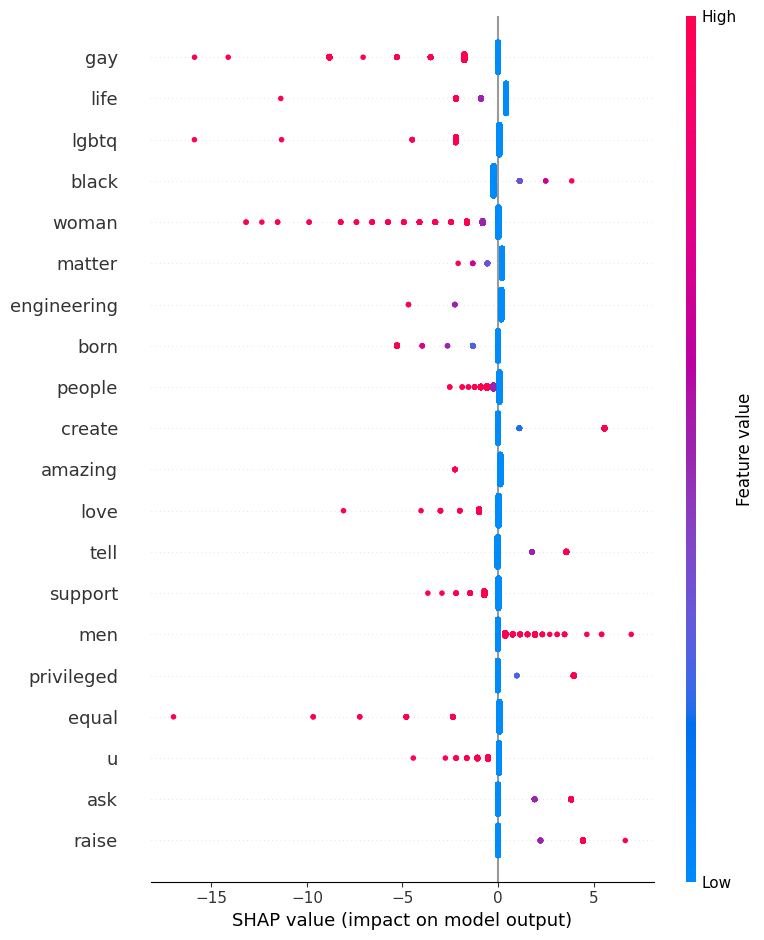

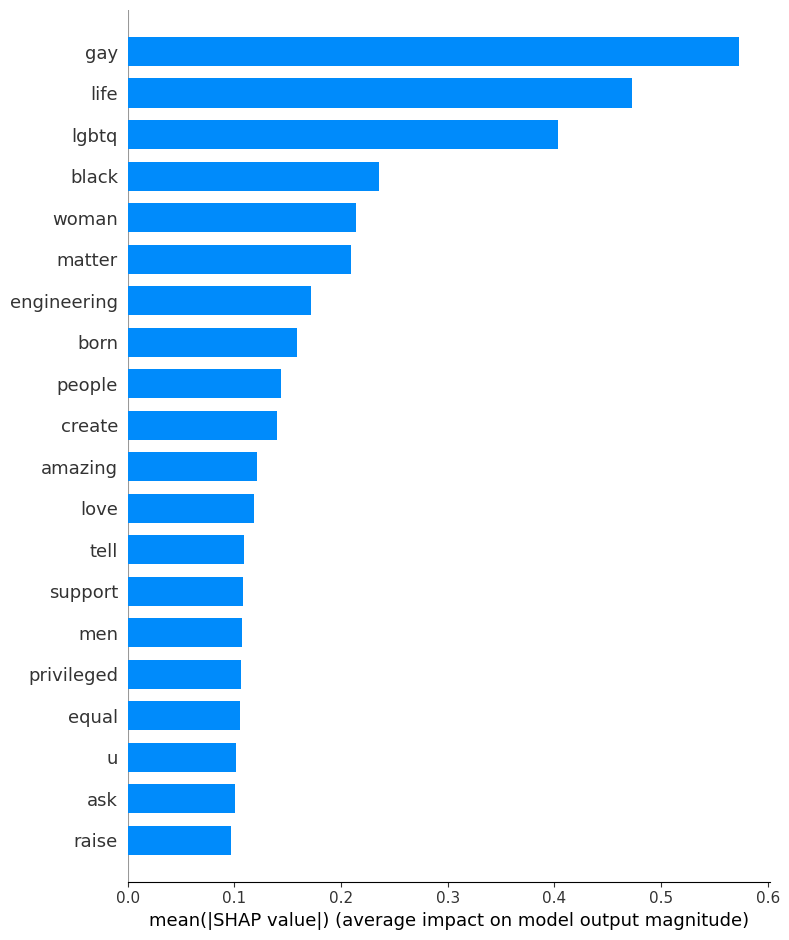

In [ ]:
explainer_logreg_bow, shap_values_logreg_bow = explainable_AI(logreg_model_bow,X_train_mybag,list(ALL_WORDS),X_test_mybag,shap.Explainer,False)

In [ ]:
print(f"TFIDF results:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_logreg_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_logreg_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_logreg_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_logreg_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_logreg_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_logreg_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


TFIDF results:

Accuracy: 0.6266
Precision: 0.5856
Recall: 0.8662
F1-score: 0.6988
Confusion Matrix:
[[1851 2933]
 [ 640 4144]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.39      0.51      4784
           1       0.59      0.87      0.70      4784

    accuracy                           0.63      9568
   macro avg       0.66      0.63      0.60      9568
weighted avg       0.66      0.63      0.60      9568



Summary plot as a whole:


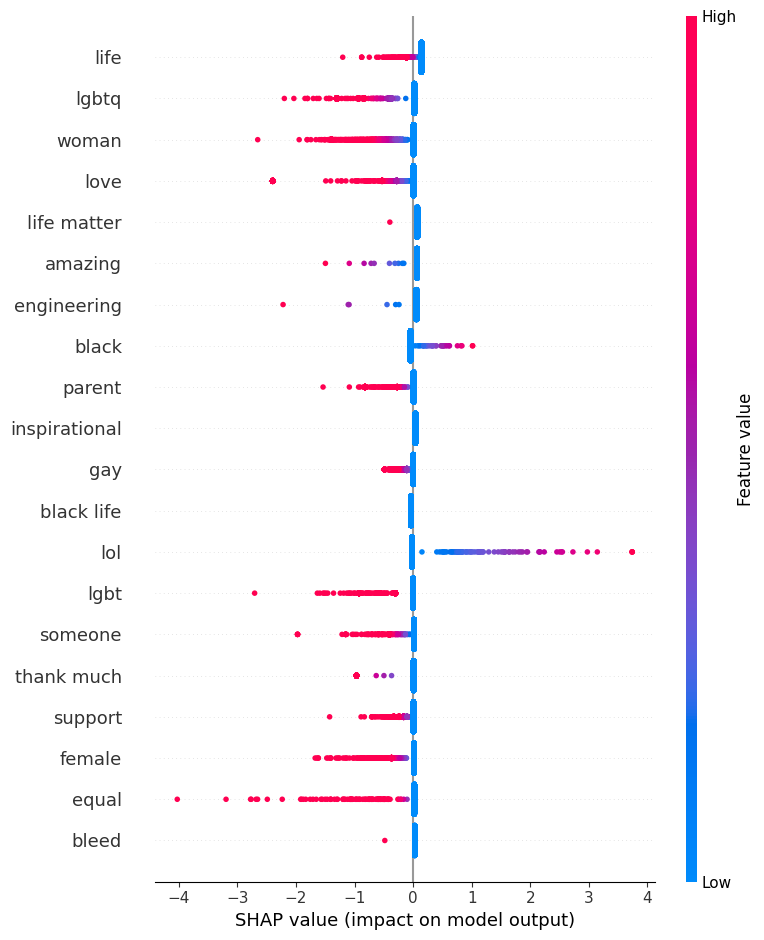

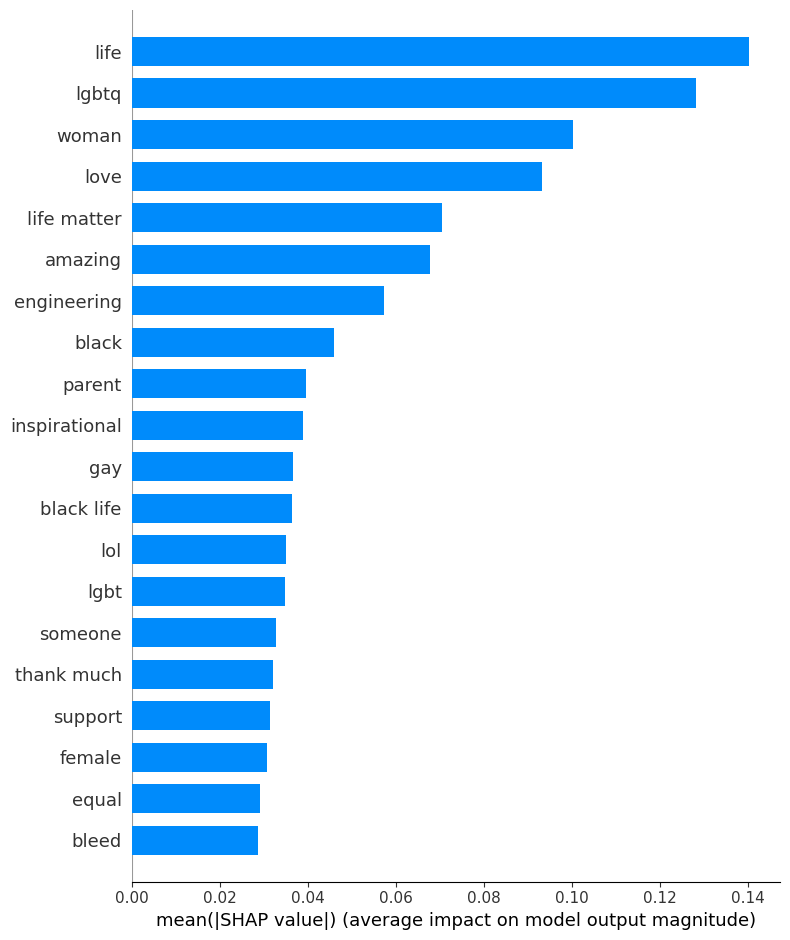

In [ ]:
explainer_logreg_tfidf, shap_values_logreg_tfidf = explainable_AI(logreg_model_tfidf,X_train_tfidf,feature_names_tfidf,X_test_tfidf,shap.Explainer)

# Linear SVC

In [ ]:
linear_svc_model = LinearSVC(random_state=42)
linear_svc_model.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_svc = linear_svc_model.predict(X_test_tfidf)

In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_svc)
y_test_svc = [label for label in decoded_y_test]
y_test_predicted_labels_svc

array([1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0])

In [ ]:
np.unique(y_test_svc)

array(['Hope_speech', 'Non_hope_speech'], dtype='<U15')

In [ ]:
df_test_undersampled['label'] = y_test_svc
df_test_undersampled['label']

0     Non_hope_speech
1         Hope_speech
2         Hope_speech
3         Hope_speech
4         Hope_speech
5     Non_hope_speech
6         Hope_speech
7     Non_hope_speech
8         Hope_speech
9         Hope_speech
10    Non_hope_speech
11        Hope_speech
12        Hope_speech
13        Hope_speech
14        Hope_speech
15        Hope_speech
16        Hope_speech
17        Hope_speech
18        Hope_speech
19        Hope_speech
20        Hope_speech
21    Non_hope_speech
22        Hope_speech
23    Non_hope_speech
24    Non_hope_speech
25    Non_hope_speech
26        Hope_speech
27    Non_hope_speech
28    Non_hope_speech
29        Hope_speech
30    Non_hope_speech
31        Hope_speech
32    Non_hope_speech
33        Hope_speech
34        Hope_speech
35    Non_hope_speech
36        Hope_speech
37    Non_hope_speech
38        Hope_speech
39    Non_hope_speech
40    Non_hope_speech
41        Hope_speech
Name: label, dtype: object

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_svc)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_svc, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_svc, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_svc, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.6905
Precision: 0.7500
Recall: 0.5714
F1-score: 0.6486


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_svc)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_svc)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[17  4]
 [ 9 12]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.81      0.72        21
           1       0.75      0.57      0.65        21

    accuracy                           0.69        42
   macro avg       0.70      0.69      0.69        42
weighted avg       0.70      0.69      0.69        42



# Multinomial Naive Bayes

In [ ]:
# Train Multinomial Naive Bayes model
mnb_model = MultinomialNB()
mnb_model.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_mnb = mnb_model.predict(X_test_tfidf)

In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_mnb)
y_test_mnb = [label for label in decoded_y_test]
y_test_predicted_labels_mnb

array([1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0])

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_mnb)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_mnb, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_mnb, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_mnb, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.6667
Precision: 0.7059
Recall: 0.5714
F1-score: 0.6316


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_mnb)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_mnb)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[16  5]
 [ 9 12]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.76      0.70        21
           1       0.71      0.57      0.63        21

    accuracy                           0.67        42
   macro avg       0.67      0.67      0.66        42
weighted avg       0.67      0.67      0.66        42



# XG Boost

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert data to DMatrix format used by XGBoost
dtrain = xgb.DMatrix(X_train_tfidf, label=y_train)
dtest = xgb.DMatrix(X_test_tfidf)

# Set XGBoost parameters (you may adjust these based on your needs)
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 4,
    'learning_rate': 0.01,
    'n_estimators': 50,
    'seed': 42
}

# Train XGBoost model
xgb_model = xgb.train(params, dtrain)

# Predict labels for the test set
y_test_predicted_labels_xgb = xgb_model.predict(dtest)
y_test_predicted_labels_xgb = [1 if pred > 0.5 else 0 for pred in y_test_predicted_labels_xgb]

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [15:37:06] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_xgb)
y_test_xgb = [label for label in decoded_y_test]
y_test_predicted_labels_xgb

[1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1]

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_xgb)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_xgb, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_xgb, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_xgb, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.5476
Precision: 0.5263
Recall: 0.9524
F1-score: 0.6780


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_xgb)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_xgb)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[ 3 18]
 [ 1 20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.14      0.24        21
           1       0.53      0.95      0.68        21

    accuracy                           0.55        42
   macro avg       0.64      0.55      0.46        42
weighted avg       0.64      0.55      0.46        42



# Ada Boost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train AdaBoost model
adaboost_model = AdaBoostClassifier(random_state=42)
adaboost_model.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_adaboost = adaboost_model.predict(X_test_tfidf)

In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_adaboost)
y_test_adaboost = [label for label in decoded_y_test]
y_test_predicted_labels_adaboost

array([0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1])

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_adaboost)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_adaboost, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_adaboost, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_adaboost, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.6190
Precision: 0.6087
Recall: 0.6667
F1-score: 0.6364


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_adaboost)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_adaboost)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[12  9]
 [ 7 14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.57      0.60        21
           1       0.61      0.67      0.64        21

    accuracy                           0.62        42
   macro avg       0.62      0.62      0.62        42
weighted avg       0.62      0.62      0.62        42



# Decision Tree

In [ ]:
# Train Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_tree = decision_tree_model.predict(X_test_tfidf)

In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_tree)
y_test_tree = [label for label in decoded_y_test]
y_test_predicted_labels_tree

array([0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0])

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_tree)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_tree, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_tree, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_tree, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.6190
Precision: 0.6316
Recall: 0.5714
F1-score: 0.6000


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrixx
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_tree)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_tree)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[14  7]
 [ 9 12]]

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.67      0.64        21
           1       0.63      0.57      0.60        21

    accuracy                           0.62        42
   macro avg       0.62      0.62      0.62        42
weighted avg       0.62      0.62      0.62        42



# Gradient Boosting

In [ ]:
# Train Gradient Boosting model
gradient_boosting_model = GradientBoostingClassifier(random_state=42)
gradient_boosting_model.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_gb = gradient_boosting_model.predict(X_test_tfidf)

In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_gb)
y_test_gb = [label for label in decoded_y_test]
y_test_predicted_labels_gb

array([0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1])

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_gb)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_gb, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_gb, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_gb, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.6190
Precision: 0.6087
Recall: 0.6667
F1-score: 0.6364


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_gb)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_gb)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[12  9]
 [ 7 14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.57      0.60        21
           1       0.61      0.67      0.64        21

    accuracy                           0.62        42
   macro avg       0.62      0.62      0.62        42
weighted avg       0.62      0.62      0.62        42



# SVM

In [ ]:
from sklearn.svm import SVC
svm_model = SVC(random_state=42)
svm_model.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_svm = svm_model.predict(X_test_tfidf)

In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_svm)
y_test_svm = [label for label in decoded_y_test]
y_test_predicted_labels_svm

array([0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0])

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_svm)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_svm, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_svm, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_svm, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.7143
Precision: 0.7368
Recall: 0.6667
F1-score: 0.7000


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_svm)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_svm)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[16  5]
 [ 7 14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.76      0.73        21
           1       0.74      0.67      0.70        21

    accuracy                           0.71        42
   macro avg       0.72      0.71      0.71        42
weighted avg       0.72      0.71      0.71        42



# Ridge Classifier

In [ ]:
from sklearn.linear_model import RidgeClassifier

# Train Ridge Classifier model
ridge_classifier_model_bow = RidgeClassifier(random_state=42)
ridge_classifier_model_bow.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_ridge_mybag = ridge_classifier_model_bow.predict(X_test_mybag)

In [ ]:
from sklearn.linear_model import RidgeClassifier

# Train Ridge Classifier model
ridge_classifier_model_tfidf = RidgeClassifier(random_state=42)
ridge_classifier_model_tfidf.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_ridge_tfidf = ridge_classifier_model_tfidf.predict(X_test_tfidf)

In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_ridge_mybag)
y_test_ridge_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_ridge_mybag

array([1, 0, 1, ..., 1, 0, 1])

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_ridge_tfidf)
y_test_ridge_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_ridge_tfidf

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
print(f"Bag of words result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_ridge_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_ridge_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_ridge_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_ridge_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_ridge_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_ridge_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Bag of words result:

Accuracy: 0.5970
Precision: 0.5681
Recall: 0.8094
F1-score: 0.6676
Confusion Matrix:
[[1840 2944]
 [ 912 3872]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.38      0.49      4784
           1       0.57      0.81      0.67      4784

    accuracy                           0.60      9568
   macro avg       0.62      0.60      0.58      9568
weighted avg       0.62      0.60      0.58      9568



Summary plot as a whole:


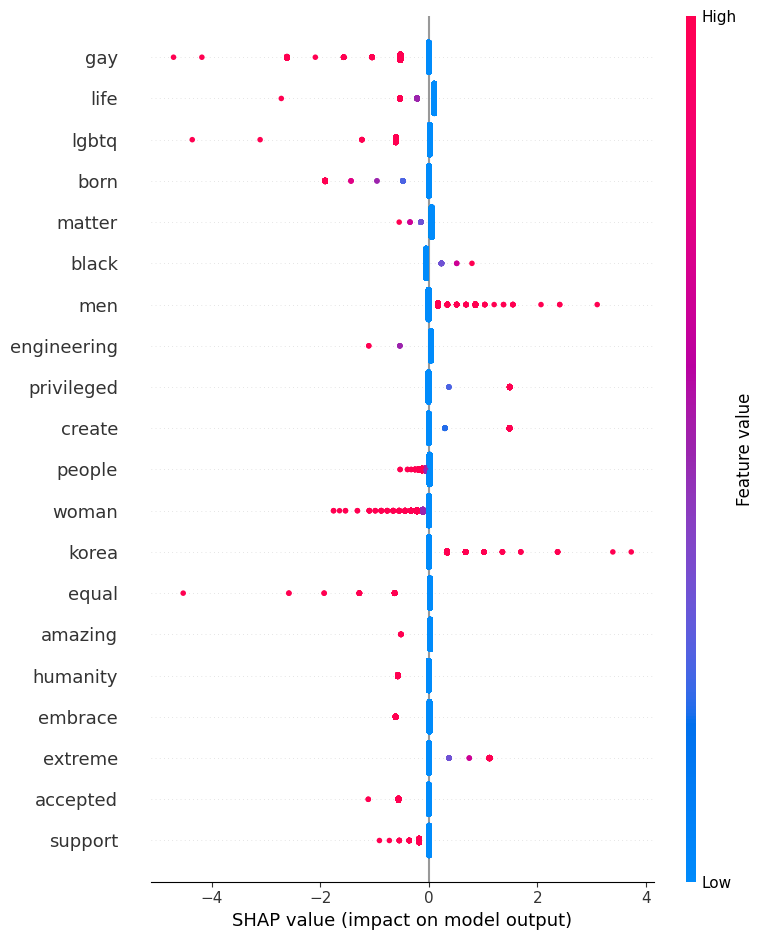

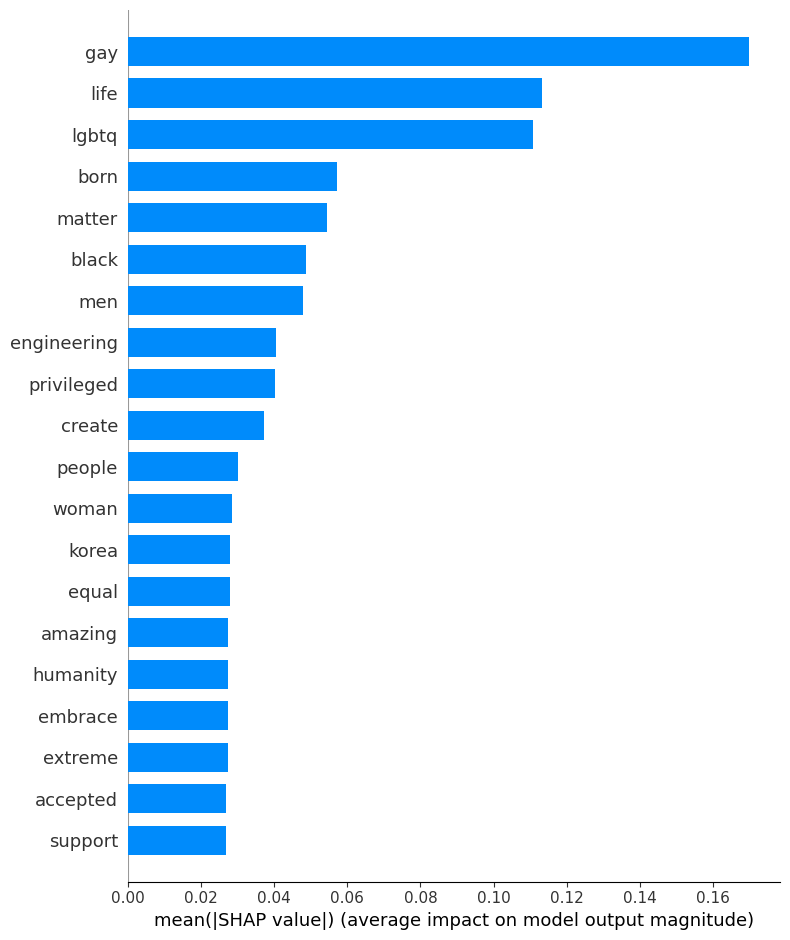

In [ ]:
explainer_ridge_bow, shap_values_ridge_bow = explainable_AI(ridge_classifier_model_bow,X_train_mybag,list(ALL_WORDS),X_test_mybag,shap.Explainer,False)

In [ ]:
print(f"TFIDF result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_ridge_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_ridge_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_ridge_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_ridge_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_ridge_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_ridge_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


TFIDF result:

Accuracy: 0.5062
Precision: 0.5032
Recall: 0.9643
F1-score: 0.6613
Confusion Matrix:
[[ 230 4554]
 [ 171 4613]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.05      0.09      4784
           1       0.50      0.96      0.66      4784

    accuracy                           0.51      9568
   macro avg       0.54      0.51      0.38      9568
weighted avg       0.54      0.51      0.38      9568



Summary plot as a whole:


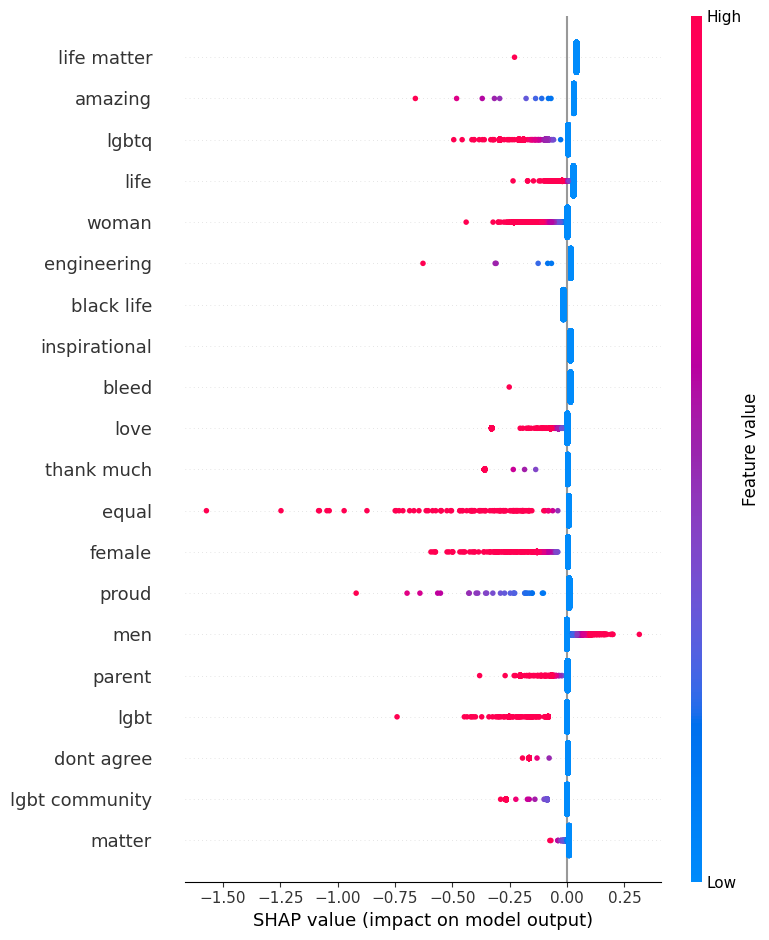

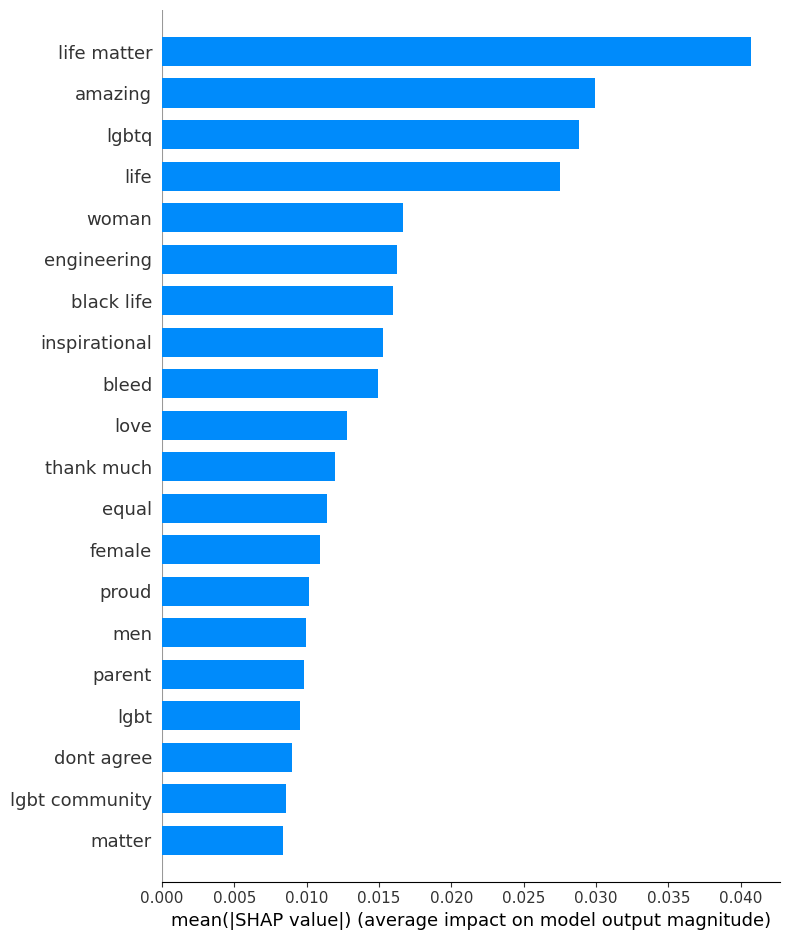

In [ ]:
explainer_ridge_tfidf, shap_values_ridge_tfidf = explainable_AI(ridge_classifier_model_tfidf,X_train_tfidf,feature_names_tfidf,X_test_tfidf,shap.Explainer)

# Perceptron Classifier

In [ ]:
from sklearn.linear_model import Perceptron

# Train Perceptron model
perceptron_model_bow = Perceptron(random_state=42)
perceptron_model_bow.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_perceptron_mybag = perceptron_model_bow.predict(X_test_mybag)


In [ ]:
# Train Perceptron model
perceptron_model_tfidf = Perceptron(random_state=42)
perceptron_model_tfidf.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_perceptron_tfidf = perceptron_model_tfidf.predict(X_test_tfidf)


In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_perceptron_mybag)
y_test_perceptron_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_perceptron_mybag

array([1, 0, 1, ..., 1, 0, 1])

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_perceptron_tfidf)
y_test_perceptron_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_perceptron_tfidf

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
print(f"Bag of words result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_perceptron_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_perceptron_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_perceptron_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_perceptron_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_perceptron_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_perceptron_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Bag of words result:

Accuracy: 0.5770
Precision: 0.5489
Recall: 0.8639
F1-score: 0.6713
Confusion Matrix:
[[1388 3396]
 [ 651 4133]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.29      0.41      4784
           1       0.55      0.86      0.67      4784

    accuracy                           0.58      9568
   macro avg       0.61      0.58      0.54      9568
weighted avg       0.61      0.58      0.54      9568



Summary plot as a whole:


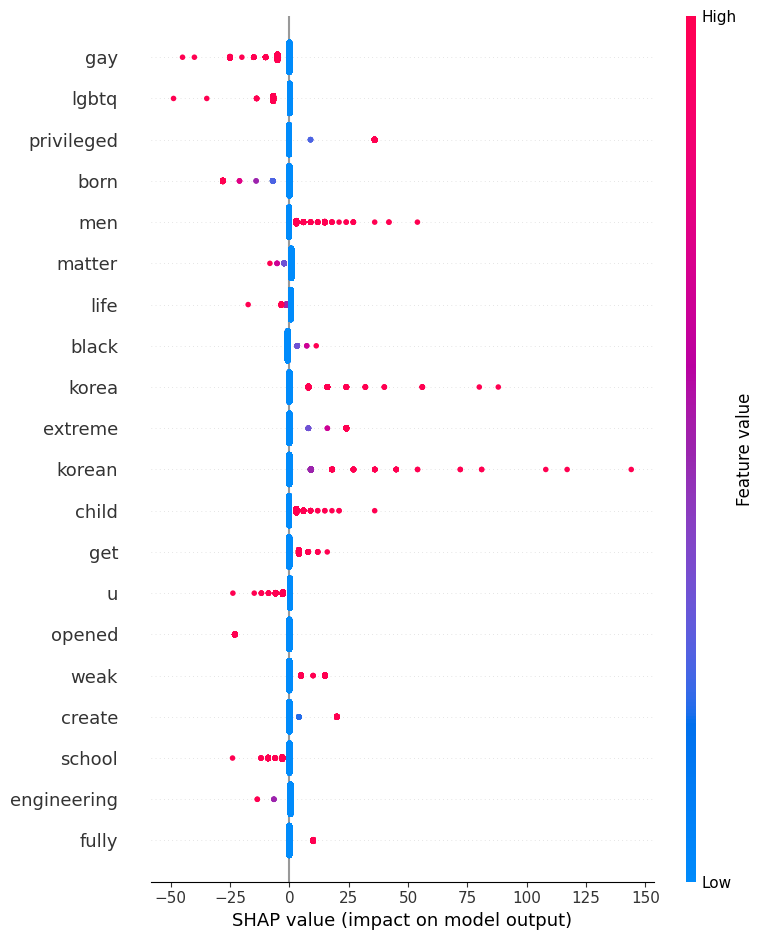

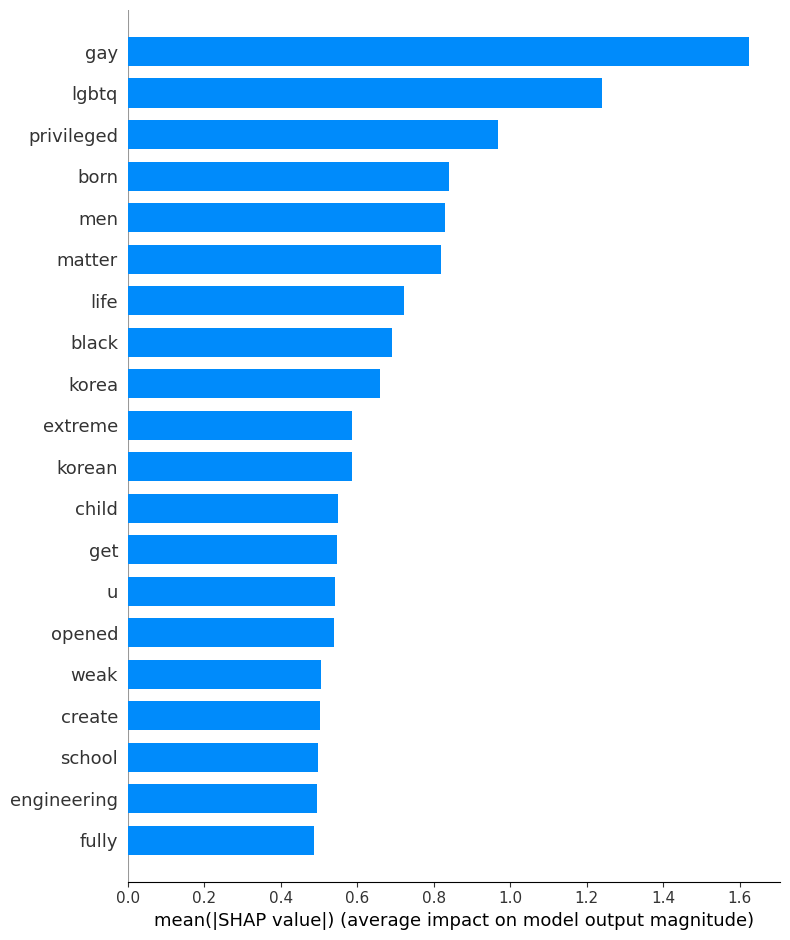

In [ ]:
explainer_perceptron_bow, shap_values_perceptron_bow = explainable_AI(perceptron_model_bow,X_train_mybag,list(ALL_WORDS),X_test_mybag,shap.Explainer,False)

In [ ]:
print(f"TFIDF results:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_perceptron_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_perceptron_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_perceptron_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_perceptron_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_perceptron_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_perceptron_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


TFIDF results:

Accuracy: 0.5054
Precision: 0.5028
Recall: 0.9628
F1-score: 0.6606
Confusion Matrix:
[[ 230 4554]
 [ 178 4606]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.05      0.09      4784
           1       0.50      0.96      0.66      4784

    accuracy                           0.51      9568
   macro avg       0.53      0.51      0.37      9568
weighted avg       0.53      0.51      0.37      9568



Summary plot as a whole:


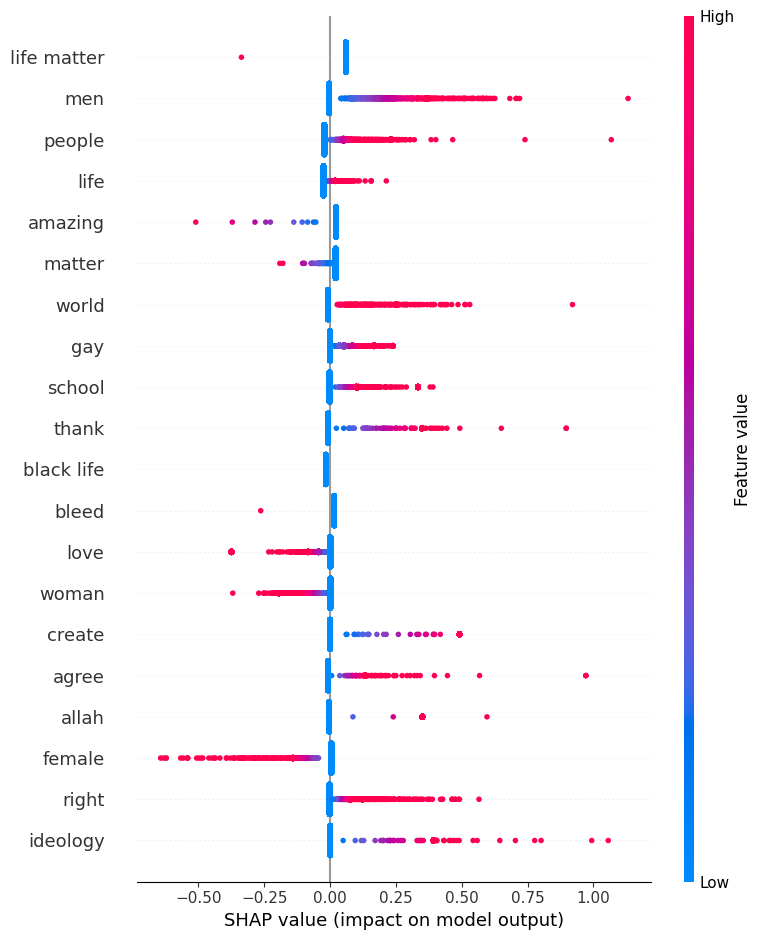

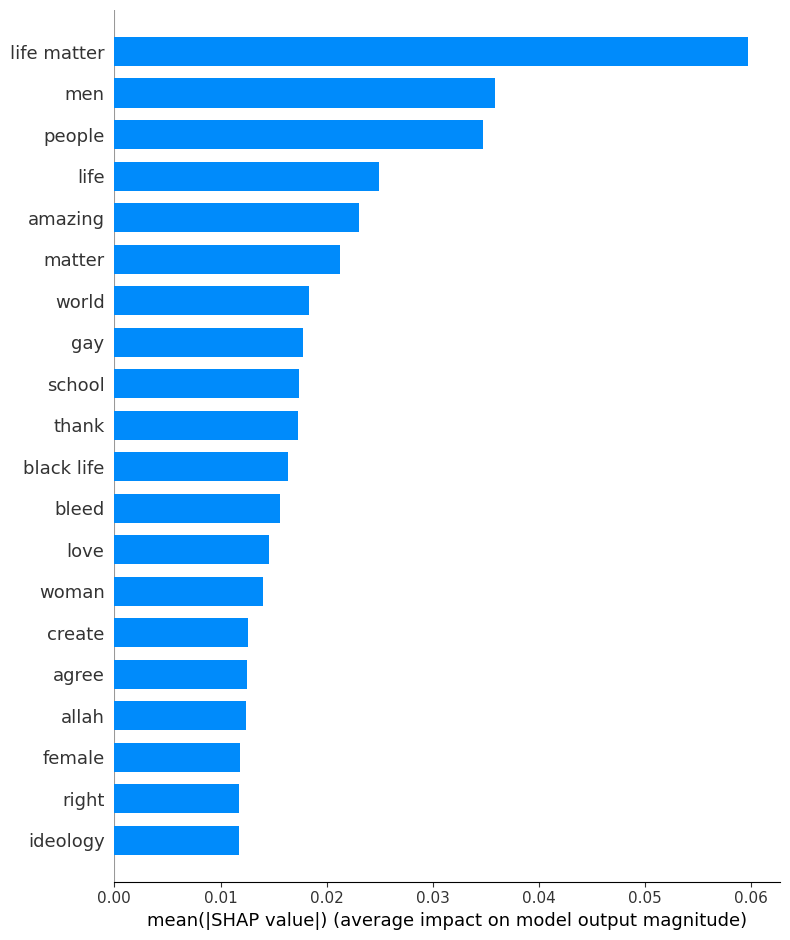

In [ ]:
explainer_perceptron_tfidf, shap_values_perceptron_tfidf = explainable_AI(perceptron_model_tfidf,X_train_tfidf,feature_names_tfidf,X_test_tfidf,shap.Explainer)

# SGD classifier

In [ ]:
from sklearn.linear_model import SGDClassifier

# Train SGD Classifier model
sgd_classifier_model_bow = SGDClassifier(random_state=42)
sgd_classifier_model_bow.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_sgd_mybag = sgd_classifier_model_bow.predict(X_test_mybag)


In [ ]:
# Train SGD Classifier model
sgd_classifier_model_tfidf = SGDClassifier(random_state=42)
sgd_classifier_model_tfidf.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_sgd_tfidf = sgd_classifier_model_tfidf.predict(X_test_tfidf)


In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_sgd_mybag)
y_test_sgd_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_sgd_mybag

array([1, 1, 1, ..., 0, 0, 1])

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_sgd_tfidf)
y_test_sgd_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_sgd_tfidf

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
print(f"Bag of words result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_sgd_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_sgd_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_sgd_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_sgd_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_sgd_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_sgd_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Bag of words result:

Accuracy: 0.6769
Precision: 0.6464
Recall: 0.7814
F1-score: 0.7075
Confusion Matrix:
[[2739 2045]
 [1046 3738]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.57      0.64      4784
           1       0.65      0.78      0.71      4784

    accuracy                           0.68      9568
   macro avg       0.69      0.68      0.67      9568
weighted avg       0.69      0.68      0.67      9568



Summary plot as a whole:


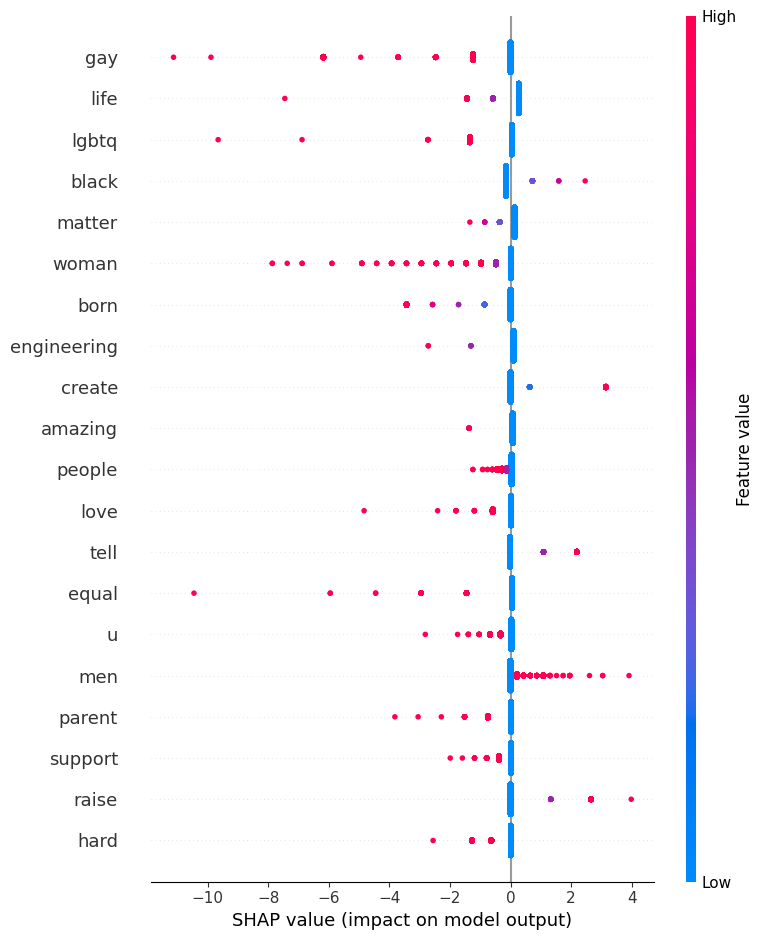

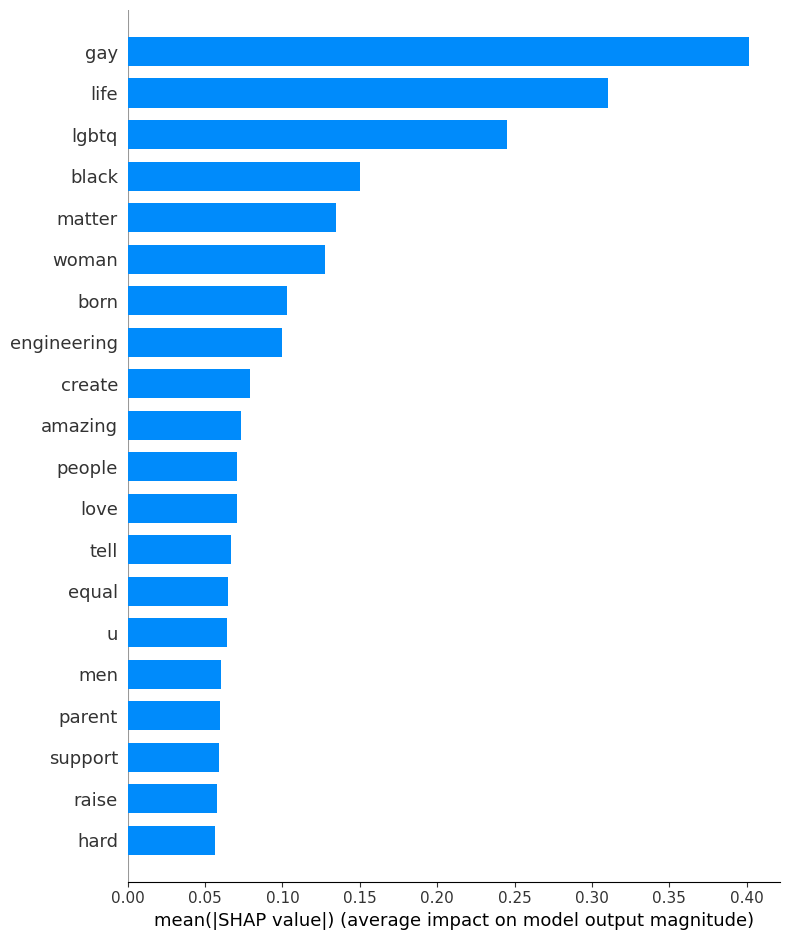

In [ ]:
explainer_sgd_bow, shap_values_sgd_bow = explainable_AI(sgd_classifier_model_bow,X_train_mybag,list(ALL_WORDS),X_test_mybag,shap.Explainer,False)

In [ ]:
print(f"TFIDF result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_sgd_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_sgd_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_sgd_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_sgd_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_sgd_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_sgd_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


TFIDF result:

Accuracy: 0.6364
Precision: 0.5966
Recall: 0.8426
F1-score: 0.6986
Confusion Matrix:
[[2058 2726]
 [ 753 4031]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.43      0.54      4784
           1       0.60      0.84      0.70      4784

    accuracy                           0.64      9568
   macro avg       0.66      0.64      0.62      9568
weighted avg       0.66      0.64      0.62      9568



Summary plot as a whole:


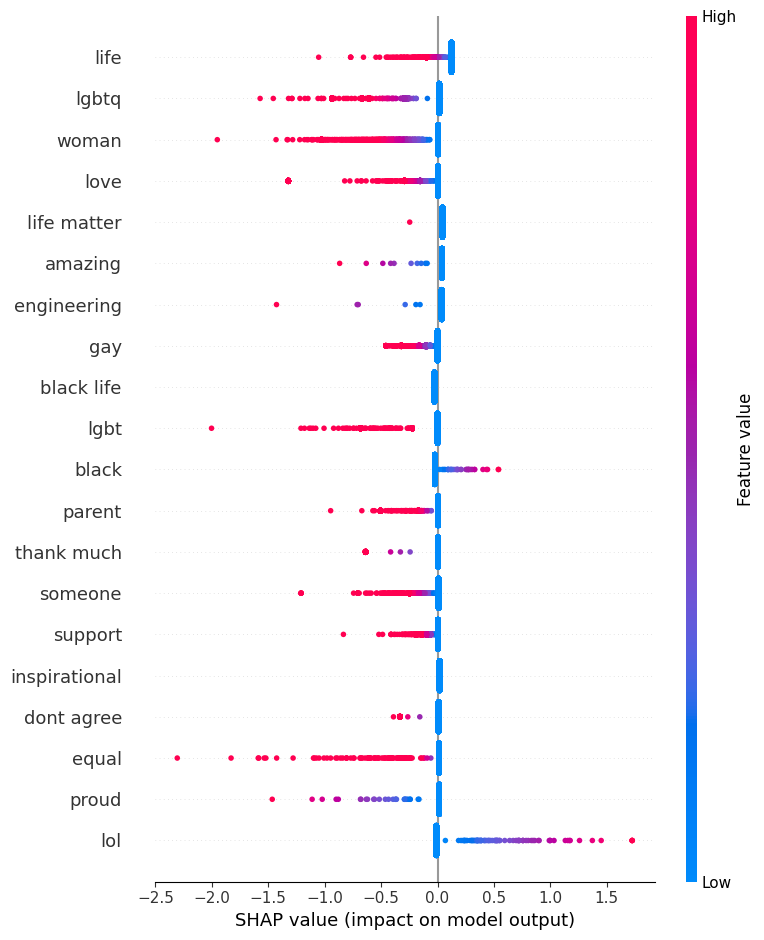

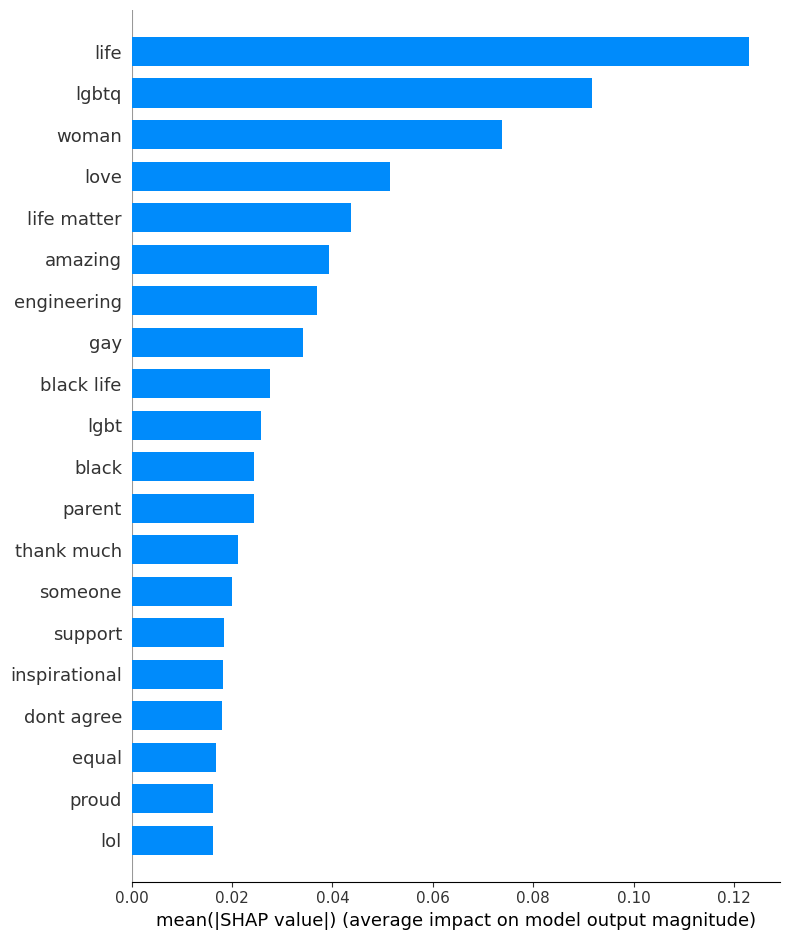

In [ ]:
explainer_sgd_tfidf, shap_values_sgd_tfidf = explainable_AI(sgd_classifier_model_tfidf,X_train_tfidf,feature_names_tfidf,X_test_tfidf,shap.Explainer)

# Passive Aggressive Classifier

In [ ]:
from sklearn.linear_model import PassiveAggressiveClassifier

# Train Passive Aggressive Classifier model
pa_classifier_model_bow = PassiveAggressiveClassifier(random_state=42)
pa_classifier_model_bow.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_pa_mybag = pa_classifier_model_bow.predict(X_test_mybag)

In [ ]:
# Train Passive Aggressive Classifier model
pa_classifier_model_tfidf = PassiveAggressiveClassifier(random_state=42)
pa_classifier_model_tfidf.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_pa_tfidf = pa_classifier_model_tfidf.predict(X_test_tfidf)

In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_pa_mybag)
y_test_pa_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_pa_mybag

array([1, 0, 1, ..., 1, 0, 1])

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_pa_tfidf)
y_test_pa_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_pa_tfidf

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
print(f"Bag of words result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_pa_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_pa_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_pa_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_pa_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_pa_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_pa_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")



Bag of words result:

Accuracy: 0.5600
Precision: 0.5390
Recall: 0.8298
F1-score: 0.6535
Confusion Matrix:
[[1388 3396]
 [ 814 3970]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.29      0.40      4784
           1       0.54      0.83      0.65      4784

    accuracy                           0.56      9568
   macro avg       0.58      0.56      0.53      9568
weighted avg       0.58      0.56      0.53      9568



Summary plot as a whole:


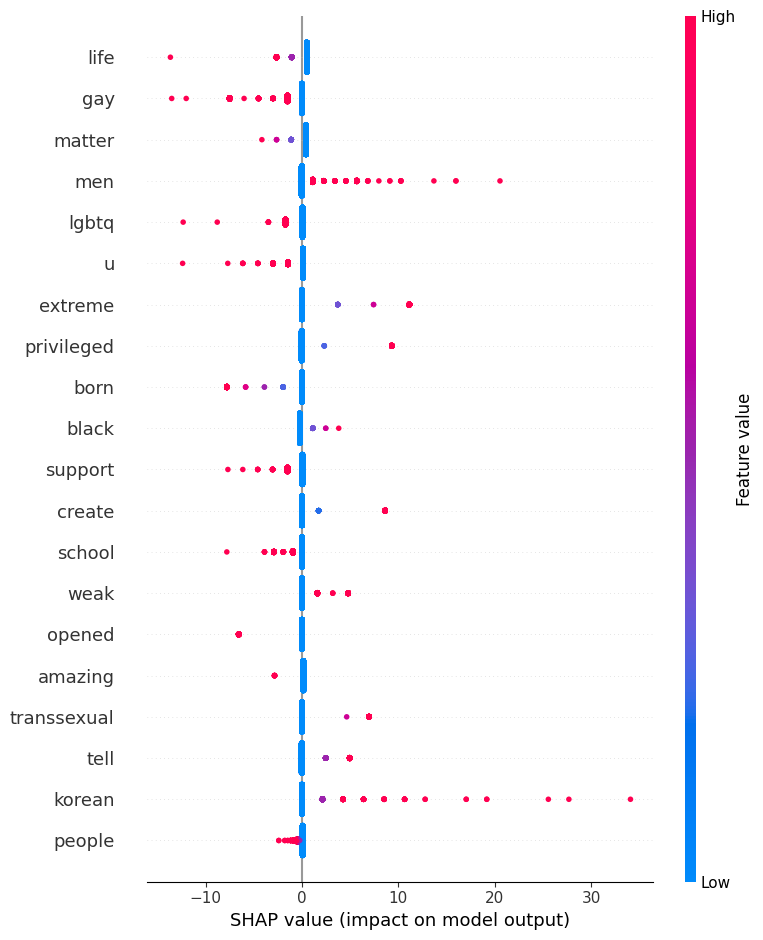

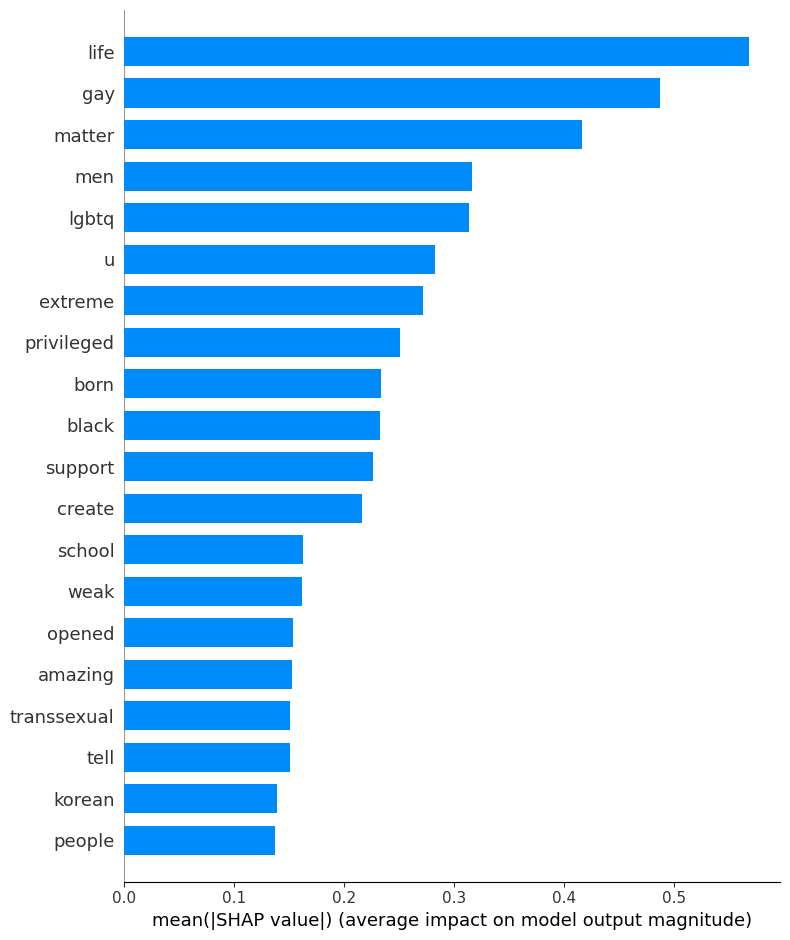

In [ ]:
explainer_pa_bow, shap_values_pa_bow = explainable_AI(pa_classifier_model_bow,X_train_mybag,list(ALL_WORDS),X_test_mybag,shap.Explainer,False)

In [ ]:
print(f"TFIDF result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_pa_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_pa_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_pa_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_pa_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_pa_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_pa_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")



TFIDF result:

Accuracy: 0.4908
Precision: 0.4954
Recall: 0.9816
F1-score: 0.6584
Confusion Matrix:
[[   0 4784]
 [  88 4696]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      4784
           1       0.50      0.98      0.66      4784

    accuracy                           0.49      9568
   macro avg       0.25      0.49      0.33      9568
weighted avg       0.25      0.49      0.33      9568



In [ ]:
explainer_pa_tfidf, shap_values_pa_tfidf = explainable_AI(pa_classifier_model_tfidf,X_train_tfidf,feature_names_tfidf,X_test_tfidf,shap.Explainer)

NameError: ignored

# Deep Learning Models

# CNN

In [ ]:
pip install tensorflow

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pandas as pd

# Assuming df_test_labels contains the true labels for the test set
# df_test_labels = pd.read_csv("/content/english/Hope_eng_test_with_labels.csv", index_col=0)
# y_true = df_test_labels['Labels']

# Tokenize and pad sequences
max_words = 10000
max_len = 100
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# Create a LabelEncoder and fit on the true labels
encoder = LabelEncoder()
encoder_2 = LabelEncoder()
y_train_encoded = encoder_2.fit_transform(y_train)
encoder.fit(y_true)

# Build CNN model
model = Sequential()
model.add(Embedding(max_words, 50, input_length=max_len))
model.add(Conv1D(128, 5, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train_pad, y_train_encoded, epochs=10, batch_size=32, validation_split=0.2)

# Convert true labels to numeric values
y_true_numeric = encoder.transform(y_true)

# Predict on the test set
y_test_probabilities = model.predict(X_test_pad)
y_test_predicted_labels_cnn = (y_test_probabilities > 0.5).astype(int)

# Convert predicted labels back to original labels
y_test_predicted_labels_cnn_str = encoder.inverse_transform(y_test_predicted_labels_cnn.flatten())

# Evaluate the model
accuracy_cnn = accuracy_score(y_true_numeric, y_test_predicted_labels_cnn)
precision_cnn = precision_score(y_true_numeric, y_test_predicted_labels_cnn, average='weighted', zero_division=0)
recall_cnn = recall_score(y_true_numeric, y_test_predicted_labels_cnn, average='weighted', zero_division=0)
f1_cnn = f1_score(y_true_numeric, y_test_predicted_labels_cnn, average='weighted', zero_division=0)

# Print the results
print(f"Accuracy: {accuracy_cnn:.4f}")
print(f"Precision: {precision_cnn:.4f}")
print(f"Recall: {recall_cnn:.4f}")
print(f"F1-score: {f1_cnn:.4f}")


Epoch 1/10
99/99 [==============================] - 4s 27ms/step - loss: 0.5939 - accuracy: 0.6811 - val_loss: 0.5543 - val_accuracy: 0.7631
Epoch 2/10
99/99 [==============================] - 4s 36ms/step - loss: 0.3763 - accuracy: 0.8452 - val_loss: 0.4805 - val_accuracy: 0.7656
Epoch 3/10
99/99 [==============================] - 2s 25ms/step - loss: 0.1826 - accuracy: 0.9356 - val_loss: 0.5690 - val_accuracy: 0.7541
Epoch 4/10
99/99 [==============================] - 2s 23ms/step - loss: 0.0835 - accuracy: 0.9748 - val_loss: 1.2978 - val_accuracy: 0.6191
Epoch 5/10
99/99 [==============================] - 2s 23ms/step - loss: 0.0499 - accuracy: 0.9863 - val_loss: 1.2433 - val_accuracy: 0.6611
Epoch 6/10
99/99 [==============================] - 2s 22ms/step - loss: 0.0307 - accuracy: 0.9904 - val_loss: 1.5406 - val_accuracy: 0.6446
Epoch 7/10
99/99 [==============================] - 3s 27ms/step - loss: 0.0272 - accuracy: 0.9917 - val_loss: 1.9093 - val_accuracy: 0.6102
Epoch 8/10
99

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_cnn)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_cnn)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[19  2]
 [ 8 13]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.90      0.79        21
           1       0.87      0.62      0.72        21

    accuracy                           0.76        42
   macro avg       0.79      0.76      0.76        42
weighted avg       0.79      0.76      0.76        42



PermutationExplainer explainer: 43it [06:25,  9.18s/it]


Summary plot as a whole:


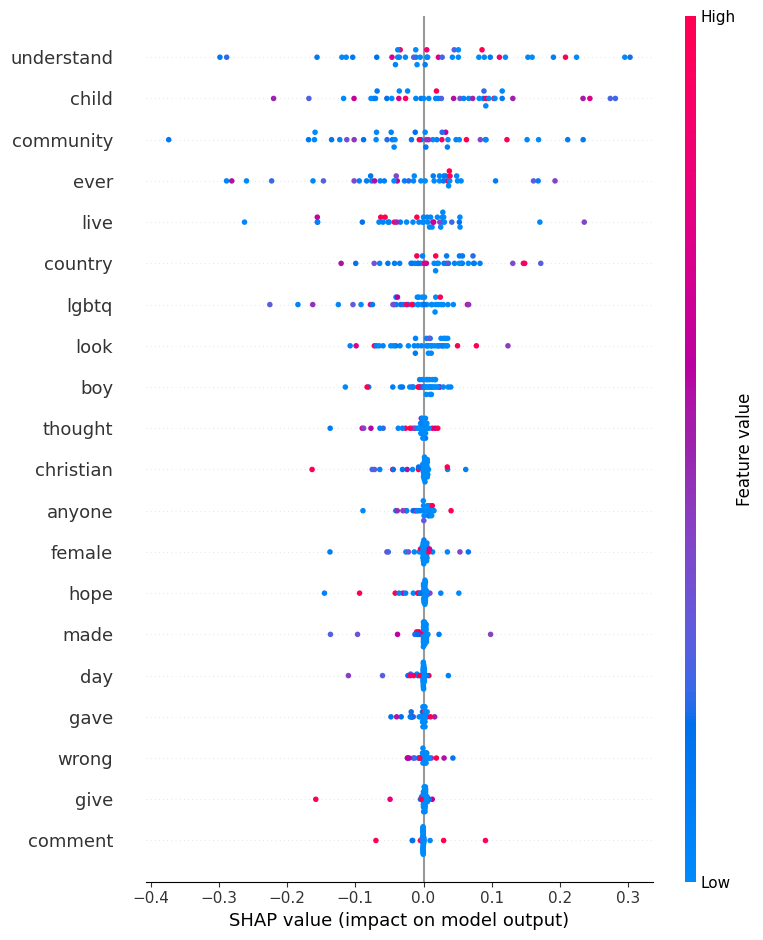

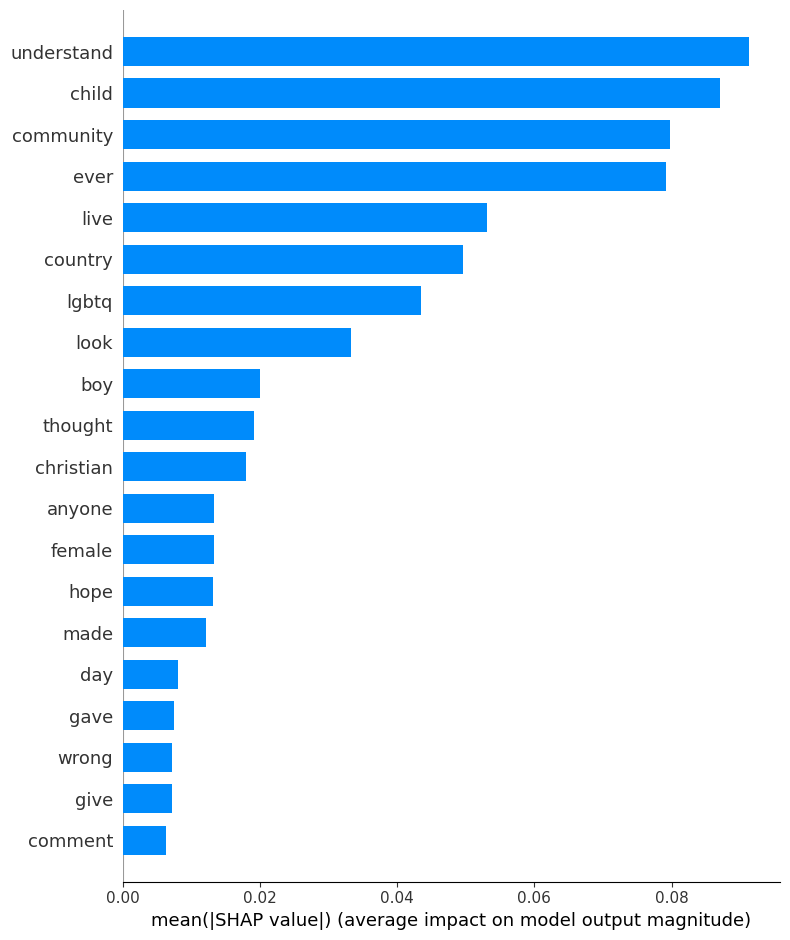

In [ ]:
explainer_cnn, shap_values_cnn = explainable_AI(model,X_train_pad,list(ALL_WORDS),X_test_pad,shap.Explainer,False)

# LSTM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize and pad sequences
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n', lower=True)
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len)

# Define the LSTM model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
# model.add(SpatialDropout1D(0.2))
model.add(LSTM(100, return_sequences=True))  # Add return_sequences=True for stacking LSTM layers
# model.add(Dropout(0.2))  # Dropout for regularization
model.add(LSTM(100))
# model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))  # Additional dense layer
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train_seq, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
y_test_prob = model.predict(X_test_seq)
y_test_pred = (y_test_prob > 0.5).astype(int)

# Convert y_true to numeric values
y_true_numeric = encoder.transform(y_true)

# Evaluate the model
accuracy_lstm = accuracy_score(y_true_numeric, y_test_pred)
precision_lstm = precision_score(y_true_numeric, y_test_pred, average='weighted', zero_division=0)
recall_lstm = recall_score(y_true_numeric, y_test_pred, average='weighted', zero_division=0)
f1_lstm = f1_score(y_true_numeric, y_test_pred, average='weighted', zero_division=0)

# Print the evaluation metrics
print(f"Accuracy: {accuracy_lstm:.4f}")
print(f"Precision: {precision_lstm:.4f}")
print(f"Recall: {recall_lstm:.4f}")
print(f"F1 Score: {f1_lstm:.4f}")


Epoch 1/10
99/99 [==============================] - 55s 511ms/step - loss: 0.5950 - accuracy: 0.6808 - val_loss: 0.3148 - val_accuracy: 0.8790
Epoch 2/10
99/99 [==============================] - 23s 229ms/step - loss: 0.3673 - accuracy: 0.8433 - val_loss: 0.6677 - val_accuracy: 0.6662
Epoch 3/10
99/99 [==============================] - 23s 231ms/step - loss: 0.2225 - accuracy: 0.9140 - val_loss: 0.6397 - val_accuracy: 0.7134
Epoch 4/10
99/99 [==============================] - 23s 236ms/step - loss: 0.1483 - accuracy: 0.9458 - val_loss: 0.9865 - val_accuracy: 0.6217
Epoch 5/10
99/99 [==============================] - 23s 237ms/step - loss: 0.1070 - accuracy: 0.9643 - val_loss: 1.2808 - val_accuracy: 0.6038
Epoch 6/10
99/99 [==============================] - 23s 234ms/step - loss: 0.0714 - accuracy: 0.9758 - val_loss: 1.5088 - val_accuracy: 0.6420
Epoch 7/10
99/99 [==============================] - 22s 223ms/step - loss: 0.0561 - accuracy: 0.9834 - val_loss: 1.8682 - val_accuracy: 0.5567

2/2 [==============================] - 1s 28ms/step
Accuracy: 0.6429
Precision: 0.6969
Recall: 0.6429
F1 Score: 0.6166


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_pred)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_pred)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[19  2]
 [13  8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.90      0.72        21
           1       0.80      0.38      0.52        21

    accuracy                           0.64        42
   macro avg       0.70      0.64      0.62        42
weighted avg       0.70      0.64      0.62        42



PermutationExplainer explainer: 43it [46:42, 66.73s/it]


Summary plot as a whole:


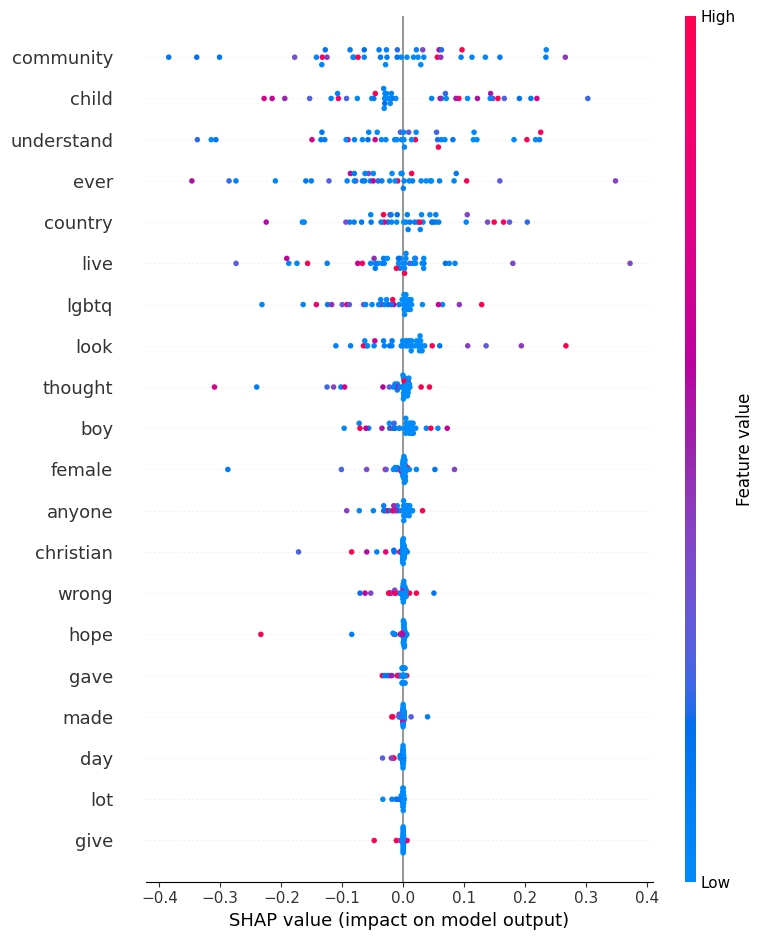

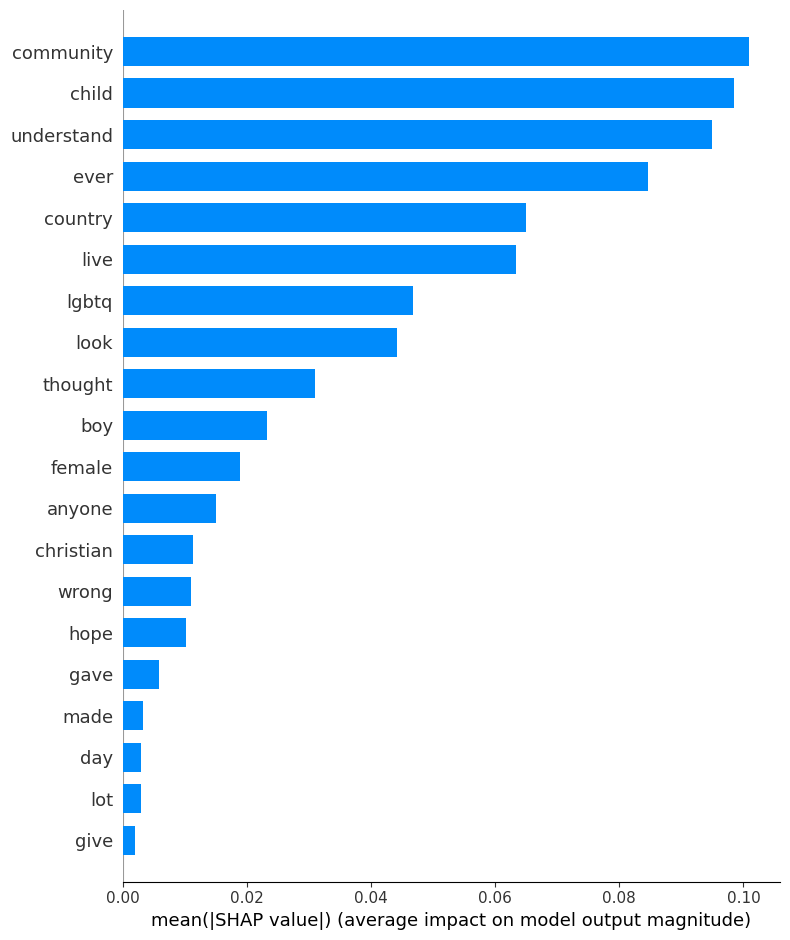

In [ ]:
explainer_lstm, shap_values_lstm = explainable_AI(model,X_train_seq,list(ALL_WORDS),X_test_seq,shap.Explainer,False)

# Bi-LSTM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize and pad sequences
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n', lower=True)
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len)

# Define the bi-LSTM model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
# model.add(SpatialDropout1D(0.2))
model.add(Bidirectional(LSTM(100)))
model.add(Dense(64, activation='relu'))  # Additional dense layer
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train_seq, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
y_test_prob_bilstm = model.predict(X_test_seq)
y_test_pred_bilstm = (y_test_prob_bilstm > 0.5).astype(int)

# Convert y_true to numeric values
y_true_numeric = encoder.transform(y_true)

# Evaluate the model
accuracy_bilstm = accuracy_score(y_true_numeric, y_test_pred_bilstm)
precision_bilstm = precision_score(y_true_numeric, y_test_pred_bilstm, average='weighted', zero_division=0)
recall_bilstm = recall_score(y_true_numeric, y_test_pred_bilstm, average='weighted', zero_division=0)
f1_bilstm = f1_score(y_true_numeric, y_test_pred_bilstm, average='weighted', zero_division=0)

# Print the evaluation metrics
print(f"Accuracy: {accuracy_bilstm:.4f}")
print(f"Precision: {precision_bilstm:.4f}")
print(f"Recall: {recall_bilstm:.4f}")
print(f"F1 Score: {f1_bilstm:.4f}")


Epoch 1/10
1039/1039 [==============================] - 292s 275ms/step - loss: 0.3132 - accuracy: 0.8675 - val_loss: 0.3380 - val_accuracy: 0.8695
Epoch 2/10
1039/1039 [==============================] - 284s 274ms/step - loss: 0.1341 - accuracy: 0.9516 - val_loss: 0.1030 - val_accuracy: 0.9840
Epoch 3/10
1039/1039 [==============================] - 286s 276ms/step - loss: 0.0790 - accuracy: 0.9730 - val_loss: 0.0882 - val_accuracy: 0.9789
Epoch 4/10
1039/1039 [==============================] - 284s 274ms/step - loss: 0.0568 - accuracy: 0.9802 - val_loss: 0.0667 - val_accuracy: 0.9865
Epoch 5/10
1039/1039 [==============================] - 286s 276ms/step - loss: 0.0427 - accuracy: 0.9855 - val_loss: 0.0459 - val_accuracy: 0.9937
Epoch 6/10
1039/1039 [==============================] - 288s 278ms/step - loss: 0.0368 - accuracy: 0.9872 - val_loss: 0.0648 - val_accuracy: 0.9795
Epoch 7/10
1039/1039 [==============================] - 283s 272ms/step - loss: 0.0302 - accuracy: 0.9896 - val_

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_pred_bilstm)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_pred_bilstm)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[ 864 3920]
 [ 503 4281]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.18      0.28      4784
           1       0.52      0.89      0.66      4784

    accuracy                           0.54      9568
   macro avg       0.58      0.54      0.47      9568
weighted avg       0.58      0.54      0.47      9568



In [ ]:
explainer_bilstm, shap_values_bilstm = explainable_AI(model,X_train_seq,list(ALL_WORDS),X_test_seq,shap.Explainer,False)

# Simple RNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Set the maximum number of words and sequence length
max_words = 10000
max_len = 100

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_len)
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len)

# Define the RNN model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(SimpleRNN(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model
model.fit(X_train_padded, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Predict on the test set
y_pred_rnn = (model.predict(X_test_padded) > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_true_numeric, y_pred_rnn)
precision = precision_score(y_true_numeric, y_pred_rnn, average='binary')
recall = recall_score(y_true_numeric, y_pred_rnn, average='binary')
f1 = f1_score(y_true_numeric, y_pred_rnn, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Epoch 1/10
520/520 [==============================] - 40s 74ms/step - loss: 0.3275 - accuracy: 0.8534 - val_loss: 0.2191 - val_accuracy: 0.9398
Epoch 2/10
520/520 [==============================] - 33s 64ms/step - loss: 0.1172 - accuracy: 0.9596 - val_loss: 0.1452 - val_accuracy: 0.9682
Epoch 3/10
520/520 [==============================] - 36s 69ms/step - loss: 0.0658 - accuracy: 0.9786 - val_loss: 0.0658 - val_accuracy: 0.9888
Epoch 4/10
520/520 [==============================] - 34s 66ms/step - loss: 0.0457 - accuracy: 0.9857 - val_loss: 0.0283 - val_accuracy: 0.9965
Epoch 5/10
520/520 [==============================] - 35s 67ms/step - loss: 0.0412 - accuracy: 0.9864 - val_loss: 0.0420 - val_accuracy: 0.9903
Epoch 6/10
520/520 [==============================] - 38s 74ms/step - loss: 0.0321 - accuracy: 0.9899 - val_loss: 0.0347 - val_accuracy: 0.9885
Epoch 7/10
520/520 [==============================] - 35s 67ms/step - loss: 0.0277 - accuracy: 0.9906 - val_loss: 0.0416 - val_accuracy:

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_pred_rnn)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_pred_rnn)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[1638 3146]
 [ 656 4128]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.34      0.46      4784
           1       0.57      0.86      0.68      4784

    accuracy                           0.60      9568
   macro avg       0.64      0.60      0.57      9568
weighted avg       0.64      0.60      0.57      9568



# DNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Set the maximum number of words and sequence length
max_words = 10000
max_len = 100

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_len)
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len)

# Define the DNN model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model
model.fit(X_train_padded, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Predict on the test set
y_pred_dnn = (model.predict(X_test_padded) > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_true_numeric, y_pred_dnn)
precision = precision_score(y_true_numeric, y_pred_dnn, average='binary')
recall = recall_score(y_true_numeric, y_pred_dnn, average='binary')
f1 = f1_score(y_true_numeric, y_pred_dnn, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_pred_dnn)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_pred_dnn)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[19  2]
 [14  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.90      0.70        21
           1       0.78      0.33      0.47        21

    accuracy                           0.62        42
   macro avg       0.68      0.62      0.59        42
weighted avg       0.68      0.62      0.59        42



PermutationExplainer explainer: 43it [05:21,  7.65s/it]


Summary plot as a whole:


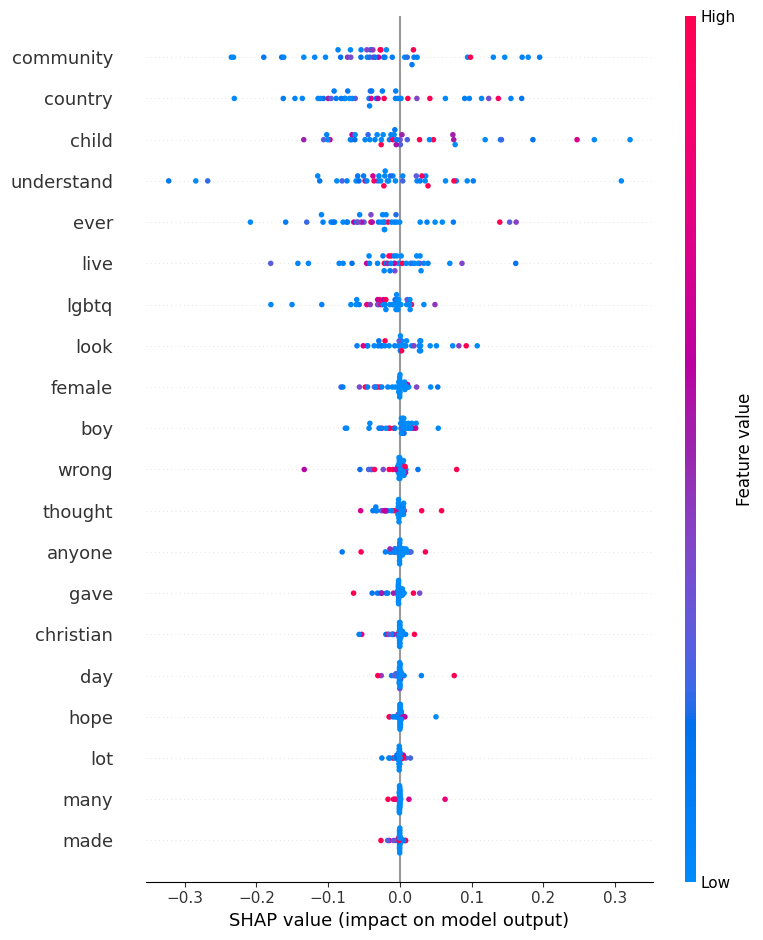

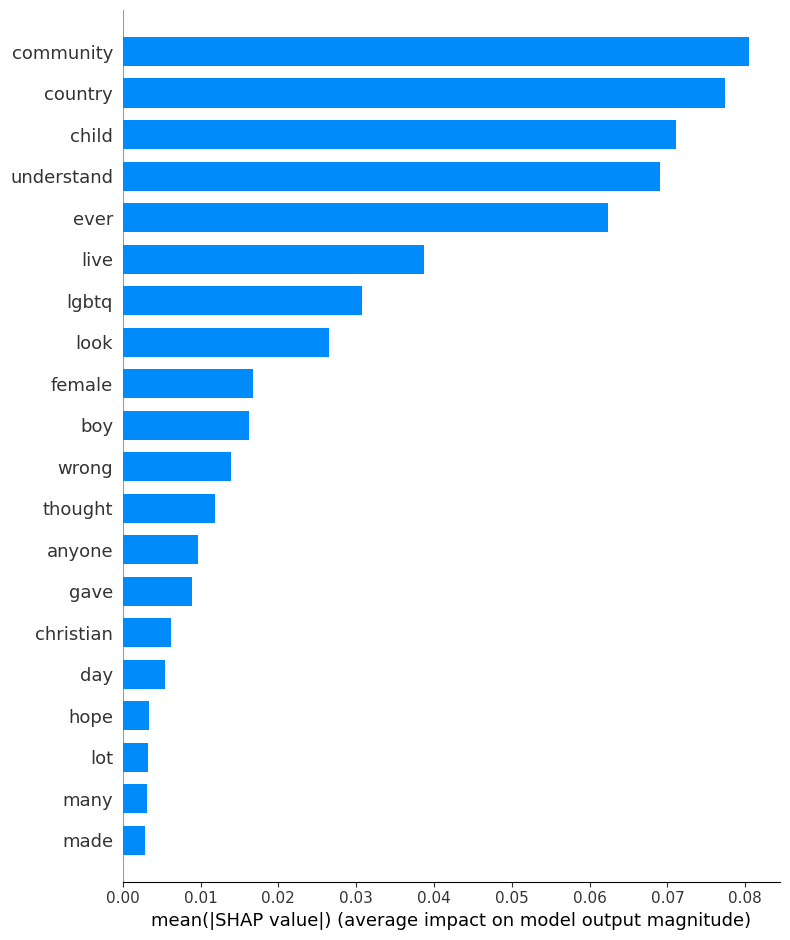

In [ ]:
explainer_dnn, shap_values_dnn = explainable_AI(model,X_train_padded,list(ALL_WORDS),X_test_padded,shap.Explainer,False)

# DNN + Embeddings

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Set the maximum number of words and sequence length
max_words = 10000
max_len = 100

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_len)
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len)

# Define the DNN+Embedding model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model
model.fit(X_train_padded, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Predict on the test set
y_pred_dnn_emb = (model.predict(X_test_padded) > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_true_numeric, y_pred_dnn_emb)
precision = precision_score(y_true_numeric, y_pred_dnn_emb, average='binary')
recall = recall_score(y_true_numeric, y_pred_dnn_emb, average='binary')
f1 = f1_score(y_true_numeric, y_pred_dnn_emb, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Epoch 1/10
50/50 [==============================] - 5s 79ms/step - loss: 0.6768 - accuracy: 0.5973 - val_loss: 0.8974 - val_accuracy: 0.0000e+00
Epoch 2/10
50/50 [==============================] - 4s 74ms/step - loss: 0.6415 - accuracy: 0.6336 - val_loss: 0.8889 - val_accuracy: 0.2318
Epoch 3/10
50/50 [==============================] - 5s 109ms/step - loss: 0.4513 - accuracy: 0.7955 - val_loss: 0.6945 - val_accuracy: 0.6943
Epoch 4/10
50/50 [==============================] - 7s 132ms/step - loss: 0.2123 - accuracy: 0.9219 - val_loss: 0.9140 - val_accuracy: 0.6573
Epoch 5/10
50/50 [==============================] - 6s 130ms/step - loss: 0.0818 - accuracy: 0.9771 - val_loss: 1.4264 - val_accuracy: 0.6051
Epoch 6/10
50/50 [==============================] - 5s 93ms/step - loss: 0.0440 - accuracy: 0.9863 - val_loss: 1.5647 - val_accuracy: 0.6013
Epoch 7/10
50/50 [==============================] - 3s 69ms/step - loss: 0.0419 - accuracy: 0.9898 - val_loss: 2.1234 - val_accuracy: 0.5325
Epoch 

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_pred_dnn_emb)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_pred_dnn_emb)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[18  3]
 [11 10]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.86      0.72        21
           1       0.77      0.48      0.59        21

    accuracy                           0.67        42
   macro avg       0.69      0.67      0.65        42
weighted avg       0.69      0.67      0.65        42



PermutationExplainer explainer: 43it [05:06,  7.67s/it]


Summary plot as a whole:


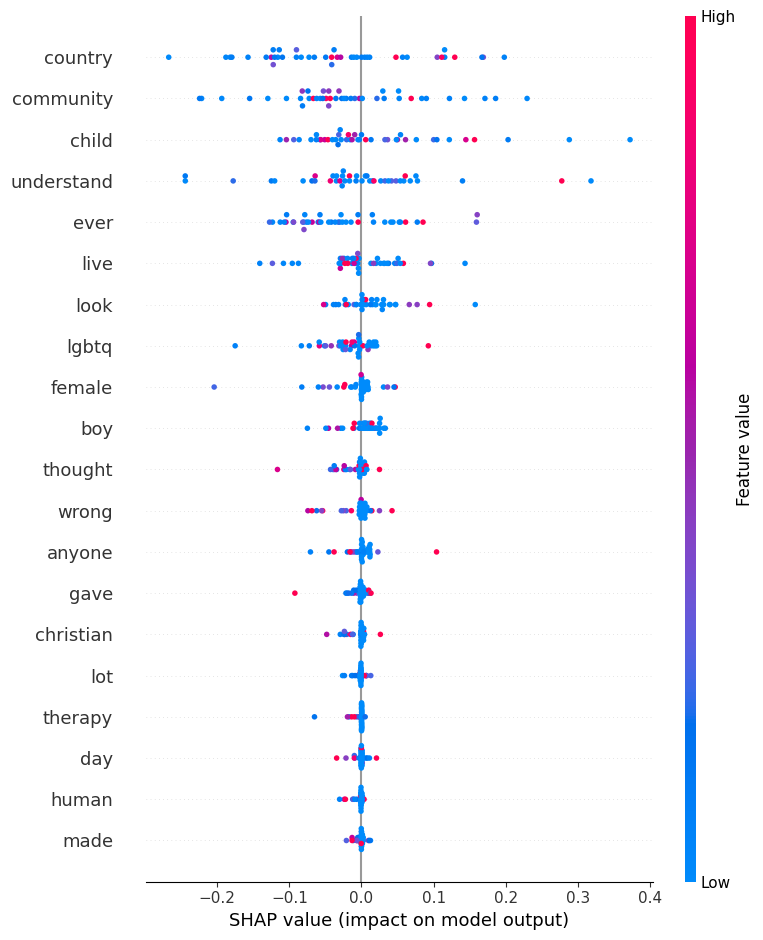

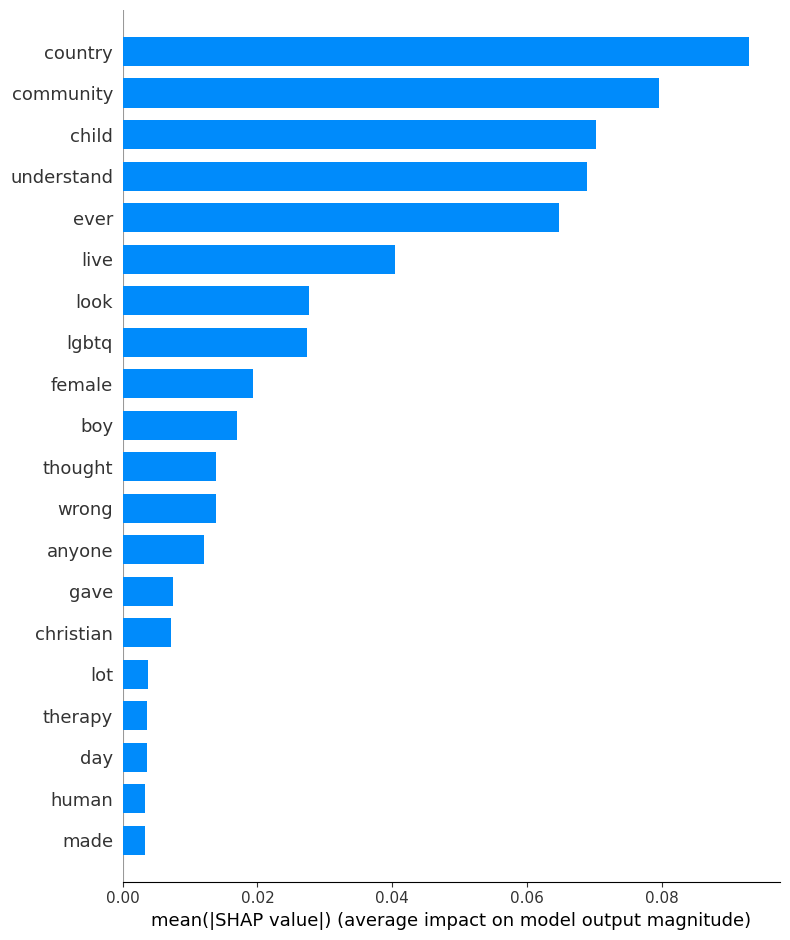

In [ ]:
explainer_dnn_emb, shap_values_dnn_emb = explainable_AI(model,X_train_padded,list(ALL_WORDS),X_test_padded,shap.Explainer,False)

# Gated Recurrence Unit(GRU)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

# Set the maximum number of words and sequence length
max_words = 10000
max_len = 100

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_len)
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len)

# # Build GRU model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(GRU(100, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

# # Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# # Train the model
model.fit(X_train_padded, y_train, epochs=10, batch_size=32, validation_split=0.2)

# # Predict on the test set
y_test_predicted_labels = (model.predict(X_test_padded) > 0.5).astype(int)

# # Calculate metrics
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels)
precision = precision_score(y_true_numeric, y_test_predicted_labels, average='binary')
recall = recall_score(y_true_numeric, y_test_predicted_labels, average='binary')
f1 = f1_score(y_true_numeric, y_test_predicted_labels, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Epoch 1/10
99/99 [==============================] - 28s 241ms/step - loss: 0.6118 - accuracy: 0.6649 - val_loss: 0.7717 - val_accuracy: 0.6752
Epoch 2/10
99/99 [==============================] - 24s 244ms/step - loss: 0.3969 - accuracy: 0.8347 - val_loss: 0.8470 - val_accuracy: 0.5401
Epoch 3/10
99/99 [==============================] - 23s 235ms/step - loss: 0.2516 - accuracy: 0.9000 - val_loss: 0.4228 - val_accuracy: 0.7924
Epoch 4/10
99/99 [==============================] - 31s 309ms/step - loss: 0.1909 - accuracy: 0.9296 - val_loss: 1.0000 - val_accuracy: 0.6115
Epoch 5/10
99/99 [==============================] - 23s 227ms/step - loss: 0.1110 - accuracy: 0.9637 - val_loss: 1.3532 - val_accuracy: 0.6089
Epoch 6/10
99/99 [==============================] - 24s 246ms/step - loss: 0.0780 - accuracy: 0.9732 - val_loss: 1.4013 - val_accuracy: 0.6471
Epoch 7/10
99/99 [==============================] - 24s 244ms/step - loss: 0.0583 - accuracy: 0.9783 - val_loss: 1.7920 - val_accuracy: 0.5605

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[18  3]
 [13  8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.86      0.69        21
           1       0.73      0.38      0.50        21

    accuracy                           0.62        42
   macro avg       0.65      0.62      0.60        42
weighted avg       0.65      0.62      0.60        42



PermutationExplainer explainer: 43it [33:53, 48.41s/it]


Summary plot as a whole:


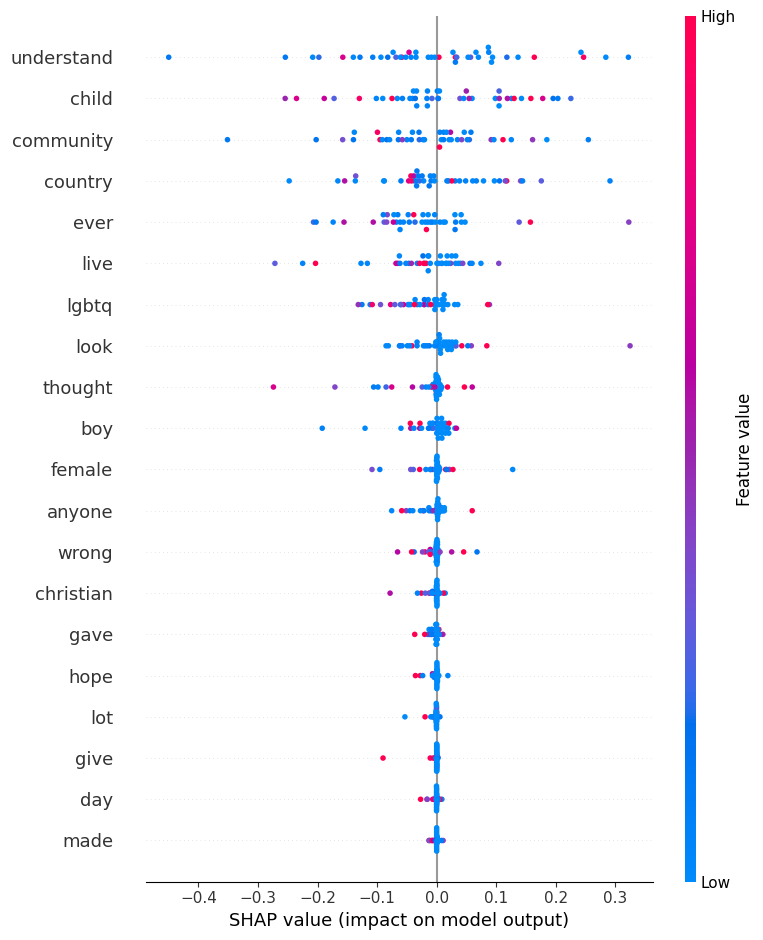

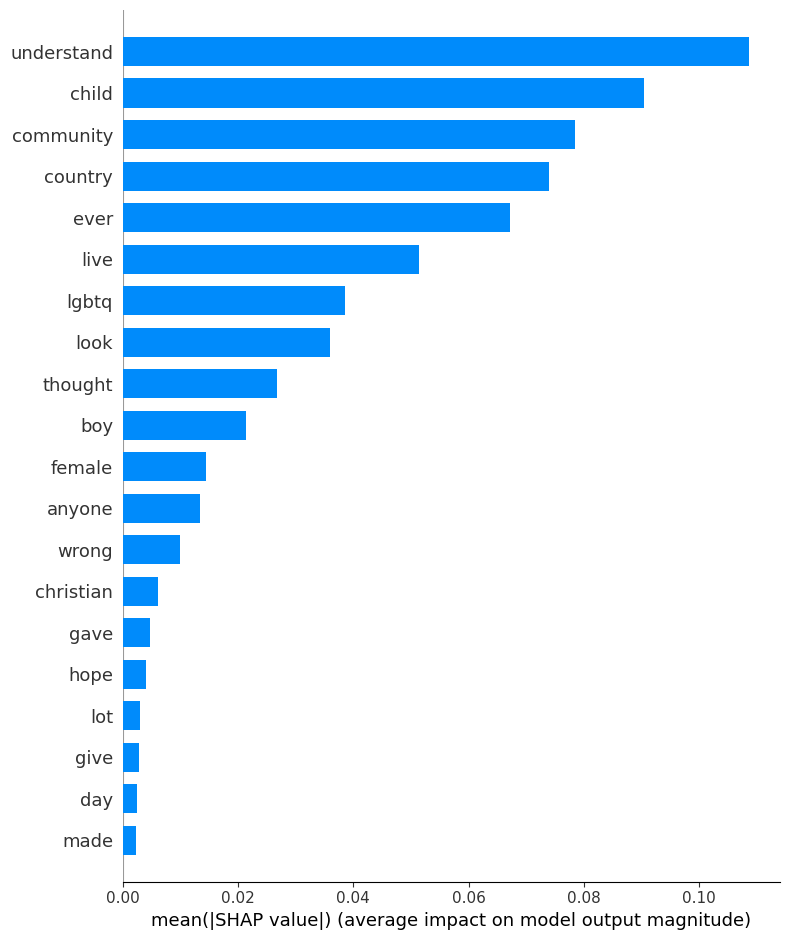

In [ ]:
explainer_gru, shap_values_gru = explainable_AI(model,X_train_padded,list(ALL_WORDS),X_test_padded,shap.Explainer,False)